# Задание 3 по финансам

## Практическое задание 4. Построение прогностических нейронных сетей для определения точек разворота и цены

В этом ноутбуке выполнено практическое задание из PDF:

1. Построены две нейронные сети для прогноза **нижней** и **верхней** точек разворота.
2. Построена нейронная сеть для прогноза **обращённого Медленного `%K`** на основе стохастического осциллятора.
3. Рассмотрены **3- и 4-слойные** сети нескольких размеров.
4. Сформированы таблицы 1–4 из условия.
5. Проведено применение на новых данных с тремя типами приказов: `market`, `limit`, `stop`.

## Важное замечание по данным

В PDF указаны даты `14.01.2013` и `16.01.2013`, но в папке `Finance/3` реально лежат файлы:

- `sber140313.txt` → **2013-03-14**
- `sber150313.txt` → **2013-03-15**
- `sber160113.txt` → **2013-01-16**

Парного файла `2013-01-14` в папке нет. Поэтому в качестве основной воспроизводимой постановки здесь принята следующая схема:

- обучение и настройка моделей: **2013-03-14**
- проверка на следующем торговом дне: **2013-03-15**
- дополнительный стресс-тест на другом режиме рынка: **2013-01-16**

Такое допущение отдельно фиксируется, чтобы решение было прозрачным и воспроизводимым.


## Формулировка задания из PDF

**1. Определение точек разворота**

Дана база данных торговли акциями Сбербанка за период в два дня. Требуется определить моменты точек разворота
(верхняя и нижняя точки — `max` и `min`) в ближайший момент времени. Для этого необходимо построить 2 нейронные сети:

- одну для прогноза **максимума**;
- одну для прогноза **минимума**.

Если вероятность минимума цены в конце торговой сессии выше некоторого порога — приказ на покупку.
Если вероятность максимума цены в конце торговой сессии выше другого порога — приказ на продажу.

**Целевая функция для моделей точек разворота:**

- `1` — нижняя точка разворота (минимум), когда цена ниже цен **трёх предыдущих** и **десяти последующих** моментов времени, иначе `0`;
- `1` — верхняя точка разворота (максимум), когда цена выше цен **трёх предыдущих** и **десяти последующих** моментов времени, иначе `0`.

**2. Прогноз цены**

Для третьей модели на основе стохастического осциллятора требуется построить сеть для прогноза значения
**обращённого Медленного `%K`**.

Для каждого момента времени вычисляется вектор входных данных

$$
x_k = \frac{x_{i-n_k} - x_i}{\sqrt{n_k}},
$$

где

$$
n_k = 10, 20, 30, 40, 50, 60, 80, 100, 120, 160, 200, 240, 320, 340, 400, 480, 640, 960.
$$

Далее длина вектора $x$ нормируется на 1:

$$
||x||_2 = 1.
$$

В условии также приведена корректировка коэффициента множественной корреляции:

$$
R_c^2 = 1 - \frac{n-1}{n-p}(1 - R^2).
$$

Для классического стохастического осциллятора используются формулы:

$$
A_i = \max(H_i, H_{i-1}, \ldots, H_{i-n+1}),
$$

$$
B_i = \min(L_i, L_{i-1}, \ldots, L_{i-n+1}),
$$

$$
D_i = \frac{A_i + A_{i-1} + A_{i-2}}{3},
\qquad
E_i = \frac{B_i + B_{i-1} + B_{i-2}}{3},
\qquad
F_i = \frac{C_i + C_{i-1} + C_{i-2}}{3},
$$

$$
\text{Slow } \%K_i = 100 \cdot \frac{F_i - E_i}{D_i - E_i}.
$$

Требуется использовать наиболее распространённую архитектуру сети с прямой связью:

- **3-слойные** и **4-слойные** сети;
- на входе — вектор $x$;
- `1–2` внутренних слоя;
- на выходе — значение Медленного `%K`.

Традиционные пороговые значения для стохастического осциллятора: **80** и **20**.

Необходимо оформить результаты:

- **Таблица 1** — показатели обучения сети для модели прогноза цены на основе стохастического осциллятора;
- **Таблица 2** — показатели обучения сети для прогноза нижних точек разворота;
- **Таблица 3** — показатели обучения сети для прогноза верхних точек разворота;
- **Таблица 4** — результаты применения моделей на новых данных.

Для таблицы 4 строки:

- название модели;
- размер сети;
- вид приказа.

Для таблицы 4 столбцы:

- доходность, `% годовых`;
- вероятность статистической достоверности;
- `% прибыльных сделок`;
- число сделок.

**Пороговые переборы по условию:**

- для обращённого Медленного `%K`: от **50** до **90** с шагом **1**;
- для моделей точек разворота: от **20** до **80** с шагом **2**.

Выход из сделки — стандартный комбинированный выход с использованием:

- `stop`;
- `limit`;
- `market`.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import ttest_1samp
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 24
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["figure.titlesize"] = 28
plt.rcParams["xtick.labelsize"] = 15
plt.rcParams["ytick.labelsize"] = 15
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["legend.title_fontsize"] = 15

RANDOM_STATE = 42

NK = [10, 20, 30, 40, 50, 60, 80, 100, 120, 160, 200, 240, 320, 340, 400, 480, 640, 960]
RET_LAGS = [1, 2, 3, 5, 10, 20, 30, 60, 120]

PRICE_ARCHS = {
    "3-layer / 16": (16,),
    "3-layer / 32": (32,),
    "4-layer / 24-12": (24, 12),
    "4-layer / 32-16": (32, 16),
}

TURN_ARCHS = {
    "3-layer / 24": (24,),
    "3-layer / 48": (48,),
    "4-layer / 32-16": (32, 16),
    "4-layer / 48-24": (48, 24),
}

RAW_COLUMNS = [
    "id", "time", "issuer", "market", "ticker", "price", "unknown1",
    "qty", "amount", "c10", "c11", "zero", "c13", "c14", "settlement", "side"
]

DATA_CANDIDATES = [
    Path("sber140313.txt"),
    Path("Finance/3/sber140313.txt"),
    Path("../3/sber140313.txt"),
]


In [2]:
def locate_data_dir() -> Path:
    for candidate in DATA_CANDIDATES:
        if candidate.exists():
            return candidate.resolve().parent
    raise FileNotFoundError("Не удалось найти папку с данными Finance/3.")


DATA_DIR = locate_data_dir()


def parse_trade_date(path: Path) -> pd.Timestamp:
    return pd.to_datetime(path.stem.replace("sber", ""), format="%d%m%y")


def align_to_intraday_clock(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    session_clock = index - index.normalize()
    return pd.DatetimeIndex(pd.Timestamp("2000-01-01") + session_clock)


def count_connections(n_inputs: int, hidden_layers: tuple[int, ...], n_outputs: int = 1) -> int:
    layers = [n_inputs, *hidden_layers, n_outputs]
    return sum(a * b for a, b in zip(layers[:-1], layers[1:]))


def adjusted_correlation(corr: float, n: int, p: int) -> float:
    if pd.isna(corr):
        return np.nan
    if n <= p or n <= 1:
        return np.nan
    r2 = corr ** 2
    rc2 = 1 - ((n - 1) / (n - p)) * (1 - r2)
    if rc2 < 0:
        return 0.0
    return float(np.sqrt(rc2))


def load_trades(path: Path) -> pd.DataFrame:
    trade_date = parse_trade_date(path)
    df = pd.read_csv(path, header=None, names=RAW_COLUMNS, encoding="cp1251")
    df["timestamp"] = pd.to_datetime(trade_date.strftime("%Y-%m-%d") + " " + df["time"])
    df["signed_qty"] = np.where(df["side"].eq("B"), df["qty"], -df["qty"])
    return df


def build_second_bars(path: Path) -> pd.DataFrame:
    trades = load_trades(path)
    trade_date = parse_trade_date(path)

    sec = (
        trades.groupby("timestamp")
        .agg(
            open=("price", "first"),
            high=("price", "max"),
            low=("price", "min"),
            close=("price", "last"),
            volume=("qty", "sum"),
            amount=("amount", "sum"),
            signed_volume=("signed_qty", "sum"),
            trades=("id", "count"),
            buy_trades=("side", lambda s: (s == "B").sum()),
            sell_trades=("side", lambda s: (s == "S").sum()),
        )
        .sort_index()
    )

    full_index = pd.date_range(sec.index.min(), sec.index.max(), freq="s")
    sec = sec.reindex(full_index)

    for col in ["open", "high", "low", "close"]:
        sec[col] = sec[col].ffill()

    for col in ["volume", "amount", "signed_volume", "trades", "buy_trades", "sell_trades"]:
        sec[col] = sec[col].fillna(0)

    sec["trade_date"] = trade_date.date()
    sec["file_name"] = path.name
    return sec


def add_features(sec: pd.DataFrame) -> pd.DataFrame:
    df = sec.copy()

    price = df["close"]

    feature_frame = {}
    for nk in NK:
        feature_frame[f"x_{nk}"] = (price.shift(nk) - price) / np.sqrt(nk)

    x_df = pd.DataFrame(feature_frame, index=df.index)
    norms = np.sqrt((x_df ** 2).sum(axis=1))
    x_df = x_df.div(norms.replace(0, np.nan), axis=0).fillna(0)
    df = pd.concat([df, x_df], axis=1)

    for lag in RET_LAGS:
        df[f"ret_{lag}"] = price.diff(lag)

    df["ema_10"] = price.ewm(span=10, adjust=False).mean()
    df["ema_30"] = price.ewm(span=30, adjust=False).mean()
    df["ema_120"] = price.ewm(span=120, adjust=False).mean()
    df["gap_ema_10"] = price - df["ema_10"]
    df["gap_ema_30"] = price - df["ema_30"]
    df["gap_ema_120"] = price - df["ema_120"]

    df["roll_std_30"] = price.diff().rolling(30).std()
    df["roll_std_120"] = price.diff().rolling(120).std()
    df["vol_mean_30"] = df["volume"].rolling(30).mean()
    df["trade_rate_30"] = df["trades"].rolling(30).mean()

    denom = df["volume"].rolling(30).sum().replace(0, np.nan)
    df["imbalance_30"] = df["signed_volume"].rolling(30).sum() / denom

    osc_window = 14
    A = df["high"].rolling(osc_window).max()
    B = df["low"].rolling(osc_window).min()
    C = df["close"]
    D = A.rolling(3).mean()
    E = B.rolling(3).mean()
    F = C.rolling(3).mean()

    slow_k = 100 * (F - E) / (D - E)
    slow_k = slow_k.replace([np.inf, -np.inf], np.nan).clip(0, 100)
    inv_slow_k = 100 - slow_k

    df["slow_k"] = slow_k
    df["inv_slow_k"] = inv_slow_k

    prev3_min = pd.concat([df["close"].shift(i) for i in [1, 2, 3]], axis=1).min(axis=1)
    next10_min = pd.concat([df["close"].shift(-i) for i in range(1, 11)], axis=1).min(axis=1)
    prev3_max = pd.concat([df["close"].shift(i) for i in [1, 2, 3]], axis=1).max(axis=1)
    next10_max = pd.concat([df["close"].shift(-i) for i in range(1, 11)], axis=1).max(axis=1)

    df["is_min_turn"] = ((df["close"] < prev3_min) & (df["close"] < next10_min)).astype(int)
    df["is_max_turn"] = ((df["close"] > prev3_max) & (df["close"] > next10_max)).astype(int)

    return df


PRICE_FEATURES = [f"x_{nk}" for nk in NK]
TURN_FEATURES = (
    PRICE_FEATURES
    + [f"ret_{lag}" for lag in RET_LAGS]
    + [
        "gap_ema_10", "gap_ema_30", "gap_ema_120",
        "roll_std_30", "roll_std_120",
        "vol_mean_30", "trade_rate_30", "imbalance_30",
        "slow_k", "inv_slow_k",
    ]
)


In [3]:
raw_files = sorted(DATA_DIR.glob("sber*.txt"))
day_bars = {path.name: build_second_bars(path) for path in raw_files}
day_data = {name: add_features(df) for name, df in day_bars.items()}


file_summary_rows = []
for path in raw_files:
    trades = load_trades(path)
    bars = day_bars[path.name]
    file_summary_rows.append(
        {
            "Файл": path.name,
            "Дата": parse_trade_date(path).date(),
            "Сделок": len(trades),
            "Уникальных секунд": trades["time"].nunique(),
            "Период": f"{trades['time'].min()} -> {trades['time'].max()}",
            "Минимальная цена": trades["price"].min(),
            "Максимальная цена": trades["price"].max(),
            "Средний объём сделки": trades["qty"].mean(),
            "Максимальный объём сделки": trades["qty"].max(),
            "Проверка amount = price * qty * 10": bool(
                ((trades["price"] * trades["qty"] * 10).round(2) == trades["amount"].round(2)).all()
            ),
            "Buy-сделок": int((trades["side"] == "B").sum()),
            "Sell-сделок": int((trades["side"] == "S").sum()),
            "Заполненных секундных баров": len(bars),
        }
    )

file_summary = pd.DataFrame(file_summary_rows)
display(Markdown("## Обзор входных файлов"))
display(file_summary)

march_14 = day_data["sber140313.txt"]
march_15 = day_data["sber150313.txt"]
jan_16 = day_data["sber160113.txt"]

overview_rows = []
for label, df in [
    ("2013-03-14", march_14),
    ("2013-03-15", march_15),
    ("2013-01-16", jan_16),
]:
    close_15s = df["close"].resample("15s").last().ffill()
    ret_15s = close_15s.diff()
    overview_rows.append(
        {
            "Дата": label,
            "Секунд в ряду": len(df),
            "Минимумов": int(df["is_min_turn"].sum()),
            "Максимумов": int(df["is_max_turn"].sum()),
            "Активных секунд, %": (df["volume"] > 0).mean() * 100,
            "Доходность от открытия, %": (df["close"].iloc[-1] / df["close"].iloc[0] - 1) * 100,
            "Дневной диапазон, %": (df["high"].max() / df["low"].min() - 1) * 100,
            "Среднее |Δцены| за 15 сек": ret_15s.abs().mean(),
        }
    )
overview = pd.DataFrame(overview_rows)
display(Markdown("## Сводка по подготовленным секундным рядам"))
display(
    overview.style.format(
        {
            "Активных секунд, %": "{:.2f}",
            "Доходность от открытия, %": "{:.3f}",
            "Дневной диапазон, %": "{:.3f}",
            "Среднее |Δцены| за 15 сек": "{:.4f}",
        }
    )
)


## Обзор входных файлов

,Файл,Дата,Сделок,Уникальных секунд,Период,Минимальная цена,Максимальная цена,Средний объём сделки,Максимальный объём сделки,Проверка amount = price * qty * 10,Buy-сделок,Sell-сделок,Заполненных секундных баров
0,sber140313.txt,2013-03-14,49004,12164,09:59:59 -> 18:49:59,103.75,105.55,144.512958,60149,True,24268,24736,31801
1,sber150313.txt,2013-03-15,52142,12487,09:59:59 -> 18:49:59,104.05,105.94,128.203176,39713,True,18491,33651,31801
2,sber160113.txt,2013-01-16,39105,11142,09:59:59 -> 18:49:59,99.19,100.13,173.309014,89262,True,17403,21702,31801


## Сводка по подготовленным секундным рядам

,Дата,Секунд в ряду,Минимумов,Максимумов,"Активных секунд, %","Доходность от открытия, %","Дневной диапазон, %",Среднее |Δцены| за 15 сек
0,2013-03-14,31801,199,247,38.25,0.354,1.735,0.0201
1,2013-03-15,31801,167,259,39.27,-1.468,1.816,0.0186
2,2013-01-16,31801,130,178,35.04,0.060,0.948,0.0146


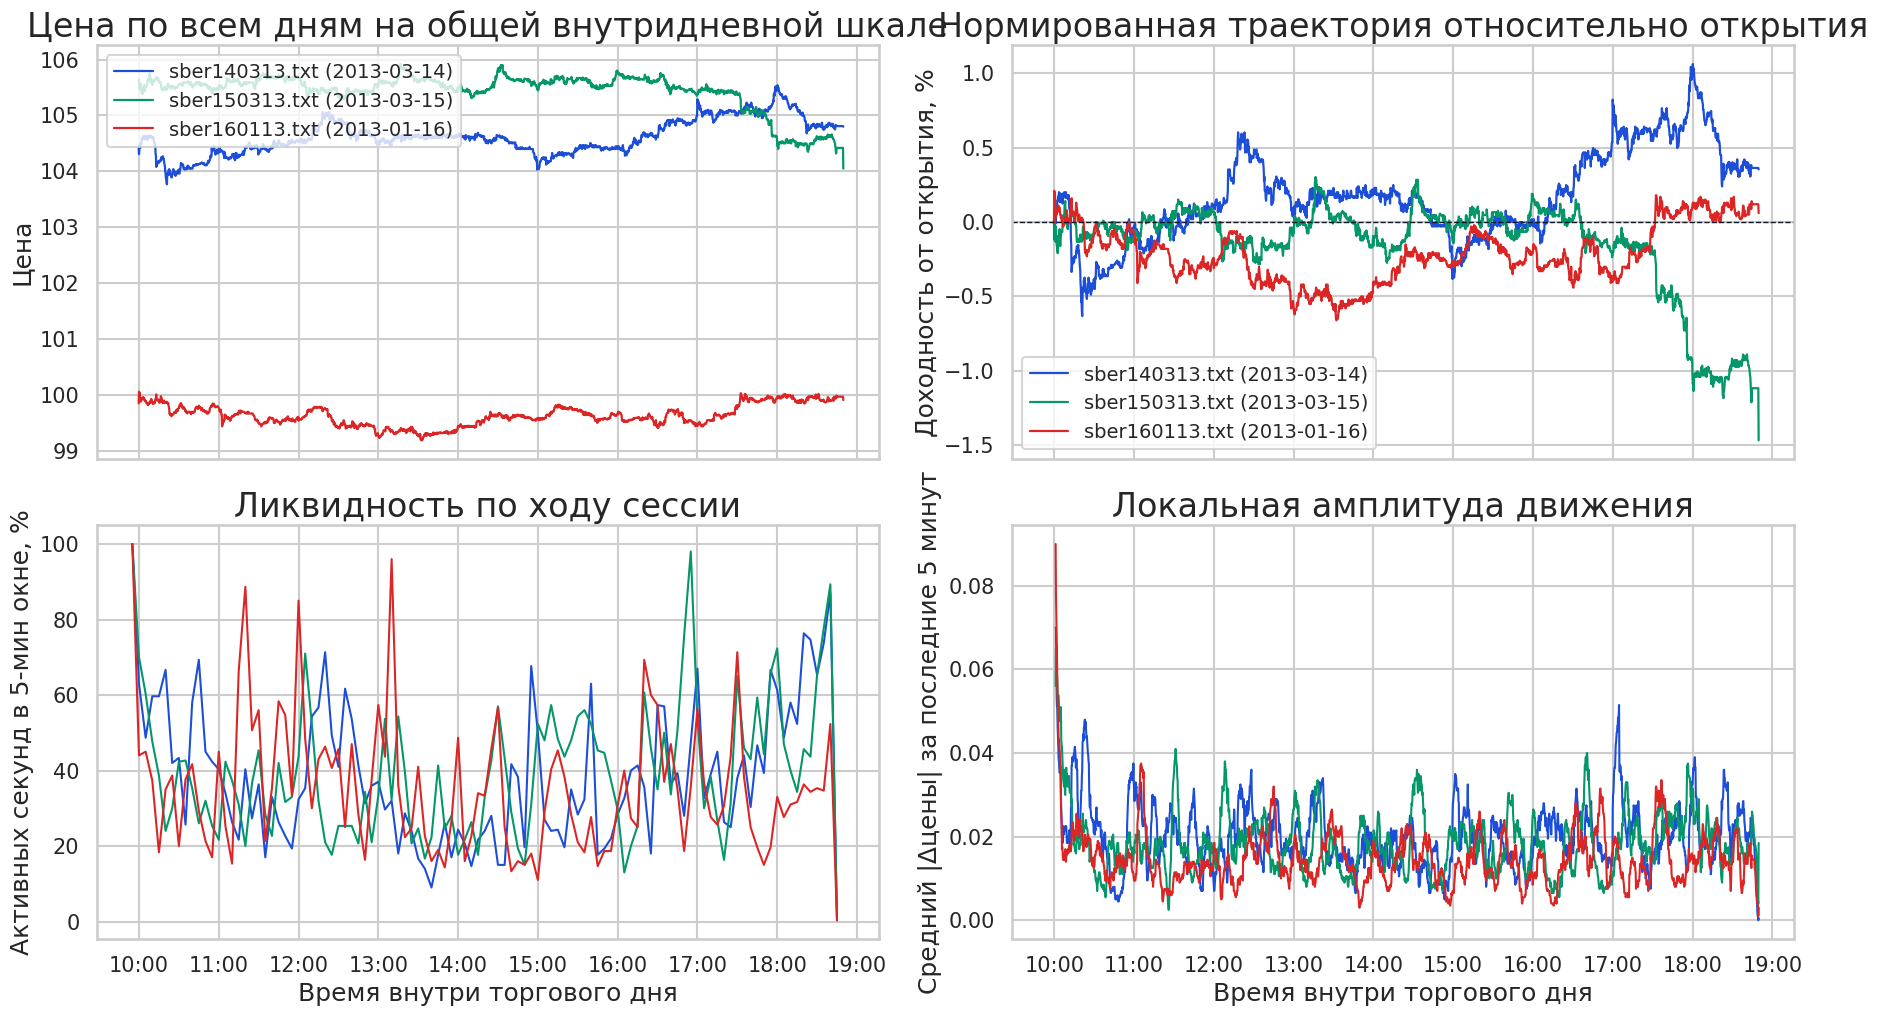

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18.5, 10.5), sharex=True)
for name, color in zip(["sber140313.txt", "sber150313.txt", "sber160113.txt"], ["#1d4ed8", "#059669", "#dc2626"]):
    df = day_data[name]
    close_15s = df["close"].resample("15s").last().ffill()
    clock_15s = align_to_intraday_clock(close_15s.index)
    normalized = (close_15s / close_15s.iloc[0] - 1) * 100
    active_share = (df["volume"] > 0).astype(float).resample("5min").mean() * 100
    active_share.index = align_to_intraday_clock(active_share.index)
    noise_profile = close_15s.diff().abs().rolling(20, min_periods=5).mean()

    label = f"{name} ({df['trade_date'].iat[0]})"
    axes[0, 0].plot(clock_15s, close_15s, label=label, linewidth=1.6, color=color)
    axes[0, 1].plot(clock_15s, normalized, label=label, linewidth=1.6, color=color)
    axes[1, 0].plot(active_share.index, active_share, label=label, linewidth=1.5, color=color)
    axes[1, 1].plot(clock_15s, noise_profile, label=label, linewidth=1.5, color=color)

axes[0, 0].set_title("Цена по всем дням на общей внутридневной шкале")
axes[0, 0].set_ylabel("Цена")
axes[0, 0].legend(loc="upper left", fontsize=14)

axes[0, 1].axhline(0, color="#111827", linestyle="--", linewidth=1.0)
axes[0, 1].set_title("Нормированная траектория относительно открытия")
axes[0, 1].set_ylabel("Доходность от открытия, %")
axes[0, 1].legend(loc="lower left", fontsize=14)

axes[1, 0].set_title("Ликвидность по ходу сессии")
axes[1, 0].set_ylabel("Активных секунд в 5-мин окне, %")
axes[1, 0].set_xlabel("Время внутри торгового дня")

axes[1, 1].set_title("Локальная амплитуда движения")
axes[1, 1].set_ylabel("Средний |Δцены| за последние 5 минут")
axes[1, 1].set_xlabel("Время внутри торгового дня")

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()


In [5]:
overview_indexed = overview.set_index("Дата")
march_range = overview_indexed.loc["2013-03-14", "Дневной диапазон, %"]
test_range = overview_indexed.loc["2013-03-15", "Дневной диапазон, %"]
stress_range = overview_indexed.loc["2013-01-16", "Дневной диапазон, %"]
march_noise = overview_indexed.loc["2013-03-14", "Среднее |Δцены| за 15 сек"]
test_noise = overview_indexed.loc["2013-03-15", "Среднее |Δцены| за 15 сек"]
stress_noise = overview_indexed.loc["2013-01-16", "Среднее |Δцены| за 15 сек"]
stress_activity = overview_indexed.loc["2013-01-16", "Активных секунд, %"]

display(Markdown("## Что видно по данным до обучения"))
display(
    Markdown(
        f'''
        - Два мартовских дня близки по масштабу движения: дневной диапазон составляет **{march_range:.2f}%** и **{test_range:.2f}%**.
        - Январский день заметно спокойнее: диапазон **{stress_range:.2f}%**, а среднее абсолютное изменение цены за 15 секунд равно **{stress_noise:.4f}**, тогда как в марте это **{march_noise:.4f}** и **{test_noise:.4f}**.
        - Ликвидность в январском дне ниже: активных секунд только **{stress_activity:.1f}%**, поэтому этот день логично использовать как стресс-тест на смену рыночного режима.
        - Метки минимумов и максимумов редкие и короткие по времени, поэтому на диагностических графиках дальше используются одновременно общий вид, zoom и сглаженная линия вероятностей.
        '''
    )
)


## Что видно по данным до обучения


        - Два мартовских дня близки по масштабу движения: дневной диапазон составляет **1.73%** и **1.82%**.
        - Январский день заметно спокойнее: диапазон **0.95%**, а среднее абсолютное изменение цены за 15 секунд равно **0.0146**, тогда как в марте это **0.0201** и **0.0186**.
        - Ликвидность в январском дне ниже: активных секунд только **35.0%**, поэтому этот день логично использовать как стресс-тест на смену рыночного режима.
        - Метки минимумов и максимумов редкие и короткие по времени, поэтому на диагностических графиках дальше используются одновременно общий вид, zoom и сглаженная линия вероятностей.
        

## Разбиение на обучение, валидацию и тест

Основная схема:

- **обучение**: первая половина дня `2013-03-14`;
- **валидация / интервал применения**: вторая половина дня `2013-03-14`;
- **новый день / out-of-sample**: `2013-03-15`;
- **дополнительный стресс-тест**: `2013-01-16`.

Это максимально близко к постановке из PDF при фактически доступных данных.


In [6]:
split_index = len(march_14) // 2
train_day = march_14.iloc[:split_index].copy()
valid_day = march_14.iloc[split_index:].copy()
test_day = march_15.copy()
stress_day = jan_16.copy()

split_summary = pd.DataFrame(
    {
        "Часть": ["Train", "Validation", "Test", "Stress"],
        "Дата": [
            train_day["trade_date"].iat[0],
            valid_day["trade_date"].iat[0],
            test_day["trade_date"].iat[0],
            stress_day["trade_date"].iat[0],
        ],
        "Строк": [len(train_day), len(valid_day), len(test_day), len(stress_day)],
        "Минимумов": [
            int(train_day["is_min_turn"].sum()),
            int(valid_day["is_min_turn"].sum()),
            int(test_day["is_min_turn"].sum()),
            int(stress_day["is_min_turn"].sum()),
        ],
        "Максимумов": [
            int(train_day["is_max_turn"].sum()),
            int(valid_day["is_max_turn"].sum()),
            int(test_day["is_max_turn"].sum()),
            int(stress_day["is_max_turn"].sum()),
        ],
    }
)
display(split_summary)


,Часть,Дата,Строк,Минимумов,Максимумов
0,Train,2013-03-14,15900,105,113
1,Validation,2013-03-14,15901,94,134
2,Test,2013-03-15,31801,167,259
3,Stress,2013-01-16,31801,130,178


In [7]:
def train_regression_models(train_df, valid_df, features, architectures):
    train_clean = train_df.dropna(subset=features + ["inv_slow_k"]).copy()
    valid_clean = valid_df.dropna(subset=features + ["inv_slow_k"]).copy()

    results = []
    models = {}

    for name, arch in architectures.items():
        pipe = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "mlp",
                    MLPRegressor(
                        hidden_layer_sizes=arch,
                        activation="tanh",
                        random_state=RANDOM_STATE,
                        max_iter=300,
                        early_stopping=True,
                        validation_fraction=0.15,
                        n_iter_no_change=20,
                        alpha=1e-4,
                    ),
                ),
            ]
        )

        pipe.fit(train_clean[features], train_clean["inv_slow_k"])

        pred_train = np.clip(pipe.predict(train_clean[features]), 0, 100)
        pred_valid = np.clip(pipe.predict(valid_clean[features]), 0, 100)

        corr_train = np.corrcoef(pred_train, train_clean["inv_slow_k"])[0, 1]
        corr_valid = np.corrcoef(pred_valid, valid_clean["inv_slow_k"])[0, 1]
        connections = count_connections(len(features), arch, 1)

        results.append(
            {
                "Название сети": name,
                "Слои": "3-layer" if len(arch) == 1 else "4-layer",
                "Размер (число нейронов)": "-".join(map(str, arch)),
                "Число связей": connections,
                "Корреляция train": corr_train,
                "Корреляция valid": corr_valid,
                "Скорр. корреляция valid": adjusted_correlation(corr_valid, len(valid_clean), connections),
                "MAE valid": mean_absolute_error(valid_clean["inv_slow_k"], pred_valid),
            }
        )
        models[name] = pipe

    result_df = pd.DataFrame(results).sort_values(["Слои", "Корреляция valid"], ascending=[True, False])
    return result_df, models, train_clean, valid_clean


def balanced_sample(train_df, target_col, features, negative_ratio=8, min_negatives=3000):
    sample_df = train_df.dropna(subset=features + [target_col]).copy()
    positives = sample_df[sample_df[target_col] == 1]
    negatives = sample_df[sample_df[target_col] == 0]
    if positives.empty:
        raise ValueError(f"В train нет положительных примеров для {target_col}.")

    neg_n = min(len(negatives), max(min_negatives, len(positives) * negative_ratio))
    negatives_sampled = negatives.sample(neg_n, random_state=RANDOM_STATE)
    return pd.concat([positives, negatives_sampled], axis=0).sample(frac=1.0, random_state=RANDOM_STATE)


def train_classifier_models(train_df, valid_df, features, target_col, architectures):
    valid_clean = valid_df.dropna(subset=features + [target_col]).copy()
    train_balanced = balanced_sample(train_df, target_col, features)

    results = []
    models = {}

    for name, arch in architectures.items():
        pipe = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "mlp",
                    MLPClassifier(
                        hidden_layer_sizes=arch,
                        activation="tanh",
                        random_state=RANDOM_STATE,
                        max_iter=300,
                        early_stopping=True,
                        validation_fraction=0.15,
                        n_iter_no_change=20,
                        alpha=1e-4,
                    ),
                ),
            ]
        )

        pipe.fit(train_balanced[features], train_balanced[target_col])
        proba_valid = pipe.predict_proba(valid_clean[features])[:, 1]

        corr_valid = np.corrcoef(proba_valid, valid_clean[target_col])[0, 1]
        auc_valid = roc_auc_score(valid_clean[target_col], proba_valid)
        connections = count_connections(len(features), arch, 1)

        results.append(
            {
                "Название сети": name,
                "Слои": "3-layer" if len(arch) == 1 else "4-layer",
                "Размер (число нейронов)": "-".join(map(str, arch)),
                "Число связей": connections,
                "Корреляция valid": corr_valid,
                "Скорр. корреляция valid": adjusted_correlation(corr_valid, len(valid_clean), connections),
                "ROC-AUC valid": auc_valid,
                "Положительных валидация": int(valid_clean[target_col].sum()),
            }
        )
        models[name] = pipe

    result_df = pd.DataFrame(results).sort_values(["Слои", "ROC-AUC valid", "Корреляция valid"], ascending=[True, False, False])
    return result_df, models, valid_clean


In [8]:
table1, price_models, price_train_clean, price_valid_clean = train_regression_models(
    train_day,
    valid_day,
    PRICE_FEATURES,
    PRICE_ARCHS,
)

display(Markdown("## Таблица 1. Модель прогноза цены на основе обращённого Медленного %K"))
display(table1.style.format({"Корреляция train": "{:.4f}", "Корреляция valid": "{:.4f}", "Скорр. корреляция valid": "{:.4f}", "MAE valid": "{:.4f}"}))


## Таблица 1. Модель прогноза цены на основе обращённого Медленного %K

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция train,Корреляция valid,Скорр. корреляция valid,MAE valid
1,3-layer / 32,3-layer,32,608,0.8231,0.7258,0.7120,21.3926
0,3-layer / 16,3-layer,16,304,0.8132,0.7247,0.7179,21.3899
2,4-layer / 24-12,4-layer,24-12,732,0.8496,0.6885,0.6688,22.4232
3,4-layer / 32-16,4-layer,32-16,1104,0.8655,0.6844,0.6530,22.4196


In [9]:
table2, min_models, min_valid_clean = train_classifier_models(
    train_day,
    valid_day,
    TURN_FEATURES,
    "is_min_turn",
    TURN_ARCHS,
)

display(Markdown("## Таблица 2. Модель прогноза нижних точек разворота"))
display(table2.style.format({"Корреляция valid": "{:.4f}", "Скорр. корреляция valid": "{:.4f}", "ROC-AUC valid": "{:.4f}"}))


## Таблица 2. Модель прогноза нижних точек разворота

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция valid,Скорр. корреляция valid,ROC-AUC valid,Положительных валидация
1,3-layer / 48,3-layer,48,1824,0.2086,0.0000,0.9232,94
0,3-layer / 24,3-layer,24,912,0.1903,0.0000,0.9087,94
3,4-layer / 48-24,4-layer,48-24,2952,0.1944,0.0000,0.8965,94
2,4-layer / 32-16,4-layer,32-16,1712,0.1849,0.0000,0.8907,94


In [10]:
table3, max_models, max_valid_clean = train_classifier_models(
    train_day,
    valid_day,
    TURN_FEATURES,
    "is_max_turn",
    TURN_ARCHS,
)

display(Markdown("## Таблица 3. Модель прогноза верхних точек разворота"))
display(table3.style.format({"Корреляция valid": "{:.4f}", "Скорр. корреляция valid": "{:.4f}", "ROC-AUC valid": "{:.4f}"}))


## Таблица 3. Модель прогноза верхних точек разворота

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция valid,Скорр. корреляция valid,ROC-AUC valid,Положительных валидация
0,3-layer / 24,3-layer,24,912,0.2555,0.0630,0.9382,134
1,3-layer / 48,3-layer,48,1824,0.2592,0.0000,0.9294,134
2,4-layer / 32-16,4-layer,32-16,1712,0.2262,0.0000,0.9008,134
3,4-layer / 48-24,4-layer,48-24,2952,0.2298,0.0000,0.8813,134


In [11]:
def pick_best_by_depth(table: pd.DataFrame, score_col: str) -> pd.DataFrame:
    best_rows = []
    for depth in ["3-layer", "4-layer"]:
        subset = table.query("Слои == @depth").sort_values(score_col, ascending=False)
        best_rows.append(subset.iloc[0])
    return pd.DataFrame(best_rows).reset_index(drop=True)


best_price = pick_best_by_depth(table1, "Корреляция valid")
best_min = pick_best_by_depth(table2, "ROC-AUC valid")
best_max = pick_best_by_depth(table3, "ROC-AUC valid")

display(Markdown("## Лучшие варианты отдельно в классе 3- и 4-слойных сетей"))
display(Markdown("### Цена / обращённый Медленный %K"))
display(best_price)
display(Markdown("### Минимумы"))
display(best_min)
display(Markdown("### Максимумы"))
display(best_max)


## Лучшие варианты отдельно в классе 3- и 4-слойных сетей

### Цена / обращённый Медленный %K

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция train,Корреляция valid,Скорр. корреляция valid,MAE valid
0,3-layer / 32,3-layer,32,608,0.823124,0.725811,0.712002,21.392569
1,4-layer / 24-12,4-layer,24-12,732,0.849645,0.688524,0.668776,22.423182


### Минимумы

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция valid,Скорр. корреляция valid,ROC-AUC valid,Положительных валидация
0,3-layer / 48,3-layer,48,1824,0.208634,0.0,0.923191,94
1,4-layer / 48-24,4-layer,48-24,2952,0.194380,0.0,0.896475,94


### Максимумы

,Название сети,Слои,Размер (число нейронов),Число связей,Корреляция valid,Скорр. корреляция valid,ROC-AUC valid,Положительных валидация
0,3-layer / 24,3-layer,24,912,0.255497,0.063,0.938163,134
1,4-layer / 32-16,4-layer,32-16,1712,0.226173,0.000,0.900793,134


In [12]:
best_price_names = best_price["Название сети"].tolist()
best_min_names = best_min["Название сети"].tolist()
best_max_names = best_max["Название сети"].tolist()


def attach_price_predictions(df: pd.DataFrame, model_name: str) -> pd.Series:
    model = price_models[model_name]
    out = pd.Series(np.nan, index=df.index, name=f"pred_price__{model_name}")
    mask = df[PRICE_FEATURES + ["inv_slow_k"]].notna().all(axis=1)
    out.loc[mask] = np.clip(model.predict(df.loc[mask, PRICE_FEATURES]), 0, 100)
    return out


def attach_classifier_predictions(df: pd.DataFrame, model_name: str, model_store: dict[str, Pipeline], prefix: str) -> pd.Series:
    model = model_store[model_name]
    out = pd.Series(np.nan, index=df.index, name=f"{prefix}__{model_name}")
    mask = df[TURN_FEATURES].notna().all(axis=1)
    out.loc[mask] = model.predict_proba(df.loc[mask, TURN_FEATURES])[:, 1] * 100
    return out


evaluation_days = {
    "validation": valid_day.copy(),
    "test": test_day.copy(),
    "stress": stress_day.copy(),
}

for dataset_name, dataset in evaluation_days.items():
    for model_name in best_price_names:
        dataset[f"pred_price__{model_name}"] = attach_price_predictions(dataset, model_name)

    for model_name in best_min_names:
        dataset[f"pred_min__{model_name}"] = attach_classifier_predictions(dataset, model_name, min_models, "pred_min")

    for model_name in best_max_names:
        dataset[f"pred_max__{model_name}"] = attach_classifier_predictions(dataset, model_name, max_models, "pred_max")

    evaluation_days[dataset_name] = dataset


In [13]:
def safe_corr(y_true: pd.Series, y_pred: pd.Series) -> float:
    if len(y_true) < 2:
        return np.nan
    if np.isclose(np.std(y_true), 0) or np.isclose(np.std(y_pred), 0):
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])


def summarize_plot_series(series: pd.Series, label: str) -> dict:
    clean = series.dropna()
    return {
        "Серия": label,
        "Точек": len(series),
        "Непустых": len(clean),
        "NaN": int(series.isna().sum()),
        "Все значения конечны": bool(np.isfinite(clean).all()) if len(clean) else False,
        "Минимум": clean.min() if len(clean) else np.nan,
        "Максимум": clean.max() if len(clean) else np.nan,
    }


def get_window(df: pd.DataFrame, start: str = "11:00", end: str = "12:30", fallback_seconds: int = 5400) -> pd.DataFrame:
    window = df.between_time(start, end)
    if len(window) >= 300:
        return window.copy()
    return df.iloc[:fallback_seconds].copy()


def select_focus_window_from_score(df: pd.DataFrame, score: pd.Series, window_minutes: int = 20) -> pd.DataFrame:
    score = score.reindex(df.index).fillna(0.0)
    window_points = max(120, window_minutes * 60)
    rolled = score.rolling(window_points, min_periods=max(60, window_points // 5)).sum()
    if rolled.notna().any() and rolled.max() > 0:
        center = rolled.idxmax()
    else:
        center = df.index[len(df) // 2]

    half = pd.Timedelta(minutes=window_minutes / 2)
    start = max(df.index.min(), center - half)
    end = min(df.index.max(), center + half)
    window = df.loc[start:end].copy()
    if len(window) < 180:
        return get_window(df)
    return window


def select_focus_window_for_trades(
    df: pd.DataFrame,
    trades: pd.DataFrame | None = None,
    extra_score: pd.Series | None = None,
    window_minutes: int = 20,
) -> pd.DataFrame:
    score = pd.Series(0.0, index=df.index)

    if extra_score is not None:
        score = score.add(extra_score.reindex(df.index).fillna(0.0), fill_value=0.0)

    if trades is not None and not trades.empty:
        for _, row in trades.iterrows():
            strength = 8.0 + min(25.0, abs(row["return"]) * 8000)
            for key, weight in [("entry_time", 1.0), ("exit_time", 0.5)]:
                ts = row[key]
                if ts in score.index:
                    score.loc[ts] += strength * weight

    return select_focus_window_from_score(df, score, window_minutes=window_minutes)


def local_peak_mask(series: pd.Series, threshold: float, neighborhood: int = 6) -> pd.Series:
    clean = series.fillna(-np.inf)
    local_max = clean.rolling(2 * neighborhood + 1, center=True, min_periods=1).max()
    return (clean >= threshold) & (clean >= local_max - 1e-12)


def regression_calibration_frame(df: pd.DataFrame, pred_col: str, target_col: str, bins: int = 12) -> pd.DataFrame:
    tmp = df[[pred_col, target_col]].dropna().copy()
    if tmp.empty:
        return pd.DataFrame(columns=["pred_mean", "actual_mean", "count"])
    q = min(bins, tmp[pred_col].nunique())
    tmp["bin"] = pd.qcut(tmp[pred_col], q=q, duplicates="drop")
    grouped = (
        tmp.groupby("bin", observed=False)
        .agg(pred_mean=(pred_col, "mean"), actual_mean=(target_col, "mean"), count=(pred_col, "size"))
        .reset_index(drop=True)
    )
    return grouped


def capture_curve_frame(y_true: pd.Series, y_score: pd.Series, max_fraction: float = 0.20, points: int = 40) -> pd.DataFrame:
    y_true = y_true.astype(int)
    order = np.argsort(-y_score.to_numpy())
    y_sorted = y_true.to_numpy()[order]
    cumulative_hits = np.cumsum(y_sorted)
    positives = max(1, int(y_true.sum()))
    fracs = np.linspace(0.01, max_fraction, points)
    rows = []
    for frac in fracs:
        top_n = max(1, int(np.ceil(len(y_sorted) * frac)))
        hits = cumulative_hits[top_n - 1]
        rows.append(
            {
                "top_share": frac * 100,
                "capture": hits / positives * 100,
                "precision": hits / top_n * 100,
            }
        )
    return pd.DataFrame(rows)


def regression_quality_row(df: pd.DataFrame, dataset_name: str, model_name: str) -> dict:
    pred_col = f"pred_price__{model_name}"
    mask = df[["inv_slow_k", pred_col]].notna().all(axis=1)
    actual = df.loc[mask, "inv_slow_k"]
    pred = df.loc[mask, pred_col]
    return {
        "Датасет": dataset_name,
        "Сеть": model_name,
        "Наблюдений": len(actual),
        "Корреляция": safe_corr(actual, pred),
        "MAE": mean_absolute_error(actual, pred),
        "RMSE": float(np.sqrt(mean_squared_error(actual, pred))),
        "Доля попаданий в зоны 20/80": float(((actual >= 80) == (pred >= 80)).mean() * 100 / 2 + ((actual <= 20) == (pred <= 20)).mean() * 100 / 2),
    }


def classifier_quality_row(df: pd.DataFrame, dataset_name: str, pred_col: str, target_col: str, label: str) -> dict:
    mask = df[[pred_col, target_col]].notna().all(axis=1)
    y_true = df.loc[mask, target_col].astype(int)
    y_score = df.loc[mask, pred_col] / 100.0
    positives = int(y_true.sum())
    top_n = max(1, positives)
    order = np.argsort(y_score.to_numpy())
    top_idx = order[-top_n:]
    precision_top_n = float(y_true.iloc[top_idx].mean()) if len(top_idx) else np.nan
    return {
        "Датасет": dataset_name,
        "Модель": label,
        "Наблюдений": len(y_true),
        "Положительных событий": positives,
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "Average precision": average_precision_score(y_true, y_score),
        "Precision@N_events": precision_top_n,
        "Максимальная вероятность": float((y_score * 100).max()),
    }


plot_health = pd.DataFrame(
    [
        summarize_plot_series(evaluation_days["test"]["close"], "Test price"),
        summarize_plot_series(evaluation_days["test"][f"pred_price__{best_price.iloc[0]['Название сети']}"], "Test predicted inv Slow %K"),
        summarize_plot_series(evaluation_days["test"]["inv_slow_k"], "Test actual inv Slow %K"),
        summarize_plot_series(evaluation_days["test"][f"pred_min__{best_min.iloc[0]['Название сети']}"], "Test min-turn probability"),
        summarize_plot_series(evaluation_days["test"][f"pred_max__{best_max.iloc[0]['Название сети']}"], "Test max-turn probability"),
    ]
)
display(Markdown("## Проверка данных для графиков"))
display(plot_health)

regression_quality = pd.DataFrame(
    [
        regression_quality_row(evaluation_days["validation"], "validation", model_name)
        for model_name in best_price_names
    ]
    + [
        regression_quality_row(evaluation_days["test"], "test", model_name)
        for model_name in best_price_names
    ]
    + [
        regression_quality_row(evaluation_days["stress"], "stress", model_name)
        for model_name in best_price_names
    ]
)
display(Markdown("## Качество регрессионной сети на разных датасетах"))
display(regression_quality.style.format({"Корреляция": "{:.4f}", "MAE": "{:.4f}", "RMSE": "{:.4f}", "Доля попаданий в зоны 20/80": "{:.2f}"}))

min_quality = pd.DataFrame(
    [
        classifier_quality_row(evaluation_days["validation"], "validation", f"pred_min__{model_name}", "is_min_turn", f"min / {model_name}")
        for model_name in best_min_names
    ]
    + [
        classifier_quality_row(evaluation_days["test"], "test", f"pred_min__{model_name}", "is_min_turn", f"min / {model_name}")
        for model_name in best_min_names
    ]
    + [
        classifier_quality_row(evaluation_days["stress"], "stress", f"pred_min__{model_name}", "is_min_turn", f"min / {model_name}")
        for model_name in best_min_names
    ]
)
max_quality = pd.DataFrame(
    [
        classifier_quality_row(evaluation_days["validation"], "validation", f"pred_max__{model_name}", "is_max_turn", f"max / {model_name}")
        for model_name in best_max_names
    ]
    + [
        classifier_quality_row(evaluation_days["test"], "test", f"pred_max__{model_name}", "is_max_turn", f"max / {model_name}")
        for model_name in best_max_names
    ]
    + [
        classifier_quality_row(evaluation_days["stress"], "stress", f"pred_max__{model_name}", "is_max_turn", f"max / {model_name}")
        for model_name in best_max_names
    ]
)
display(Markdown("## Качество модели нижних разворотов"))
display(min_quality.style.format({"ROC-AUC": "{:.4f}", "Average precision": "{:.4f}", "Precision@N_events": "{:.4f}", "Максимальная вероятность": "{:.2f}"}))
display(Markdown("## Качество модели верхних разворотов"))
display(max_quality.style.format({"ROC-AUC": "{:.4f}", "Average precision": "{:.4f}", "Precision@N_events": "{:.4f}", "Максимальная вероятность": "{:.2f}"}))


## Проверка данных для графиков

,Серия,Точек,Непустых,NaN,Все значения конечны,Минимум,Максимум
0,Test price,31801,31801,0,True,104.050000,105.940000
1,Test predicted inv Slow %K,31801,29282,2519,True,0.000000,100.000000
2,Test actual inv Slow %K,31801,29282,2519,True,0.000000,100.000000
3,Test min-turn probability,31801,28888,2913,True,2.237216,91.355137
4,Test max-turn probability,31801,28888,2913,True,0.043520,89.311305


## Качество регрессионной сети на разных датасетах

,Датасет,Сеть,Наблюдений,Корреляция,MAE,RMSE,Доля попаданий в зоны 20/80
0,validation,3-layer / 32,15075,0.7258,21.3926,27.2115,78.36
1,validation,4-layer / 24-12,15075,0.6885,22.4232,29.0768,77.22
2,test,3-layer / 32,29282,0.7008,22.6897,28.9025,77.51
3,test,4-layer / 24-12,29282,0.6737,23.3278,30.2821,76.88
4,stress,3-layer / 32,28053,0.7592,21.8357,27.5244,78.38
5,stress,4-layer / 24-12,28053,0.7299,22.3222,28.9604,78.13


## Качество модели нижних разворотов

,Датасет,Модель,Наблюдений,Положительных событий,ROC-AUC,Average precision,Precision@N_events,Максимальная вероятность
0,validation,min / 3-layer / 48,14801,94,0.9232,0.0968,0.1915,87.95
1,validation,min / 4-layer / 48-24,14801,94,0.8965,0.0827,0.1915,92.51
2,test,min / 3-layer / 48,28888,167,0.9058,0.0764,0.1138,91.36
3,test,min / 4-layer / 48-24,28888,167,0.8899,0.0755,0.1437,95.16
4,stress,min / 3-layer / 48,27923,128,0.9116,0.0454,0.0547,82.37
5,stress,min / 4-layer / 48-24,27923,128,0.8870,0.0409,0.0781,85.90


## Качество модели верхних разворотов

,Датасет,Модель,Наблюдений,Положительных событий,ROC-AUC,Average precision,Precision@N_events,Максимальная вероятность
0,validation,max / 3-layer / 24,14801,134,0.9382,0.1190,0.1716,83.57
1,validation,max / 4-layer / 32-16,14801,134,0.9008,0.1199,0.1567,73.36
2,test,max / 3-layer / 24,28888,256,0.9420,0.1494,0.2109,89.31
3,test,max / 4-layer / 32-16,28888,256,0.8991,0.1194,0.1562,86.73
4,stress,max / 3-layer / 24,27923,175,0.9540,0.1117,0.1200,80.54
5,stress,max / 4-layer / 32-16,27923,175,0.8887,0.0913,0.1200,75.34


In [14]:
def make_price_signal(df: pd.DataFrame, model_name: str, threshold: int) -> pd.Series:
    pred = df[f"pred_price__{model_name}"]
    signal = pd.Series(0, index=df.index)
    signal[pred >= threshold] = 1
    signal[pred <= 100 - threshold] = -1
    return signal


def make_turn_signal(df: pd.DataFrame, min_model_name: str, max_model_name: str, threshold: int) -> pd.Series:
    min_pred = df[f"pred_min__{min_model_name}"]
    max_pred = df[f"pred_max__{max_model_name}"]

    signal = pd.Series(0, index=df.index)
    long_mask = min_pred >= threshold
    short_mask = max_pred >= threshold

    signal[long_mask & ~short_mask] = 1
    signal[short_mask & ~long_mask] = -1

    both = long_mask & short_mask
    signal[both & (min_pred > max_pred)] = 1
    signal[both & (max_pred >= min_pred)] = -1
    return signal


def simulate_strategy(
    df: pd.DataFrame,
    signals: pd.Series,
    order_type: str,
    entry_window_seconds: int = 60,
    max_hold_seconds: int = 600,
    cooldown_seconds: int = 30,
):
    data = df.copy()

    vol = data["roll_std_120"].fillna(data["roll_std_120"].median()).clip(lower=0.01)
    entry_offsets = (2.0 * vol).clip(0.02, 0.08).round(2)
    stop_offsets = (4.0 * vol).clip(0.05, 0.18).round(2)
    take_offsets = (6.0 * vol).clip(0.08, 0.28).round(2)

    trades = []
    i = 0
    idx = data.index

    while i < len(data) - max_hold_seconds - 2:
        direction = signals.iat[i]
        if direction == 0:
            i += 1
            continue

        base_price = data["close"].iat[i]
        offset = entry_offsets.iat[i]
        entry_idx = None
        entry_price = None

        if order_type == "market":
            entry_idx = i + 1
            entry_price = data["open"].iat[entry_idx]
        elif order_type == "limit":
            target = base_price - offset if direction == 1 else base_price + offset
            for j in range(i + 1, min(i + 1 + entry_window_seconds, len(data))):
                low = data["low"].iat[j]
                high = data["high"].iat[j]
                if direction == 1 and low <= target:
                    entry_idx = j
                    entry_price = target
                    break
                if direction == -1 and high >= target:
                    entry_idx = j
                    entry_price = target
                    break
        elif order_type == "stop":
            target = base_price + offset if direction == 1 else base_price - offset
            for j in range(i + 1, min(i + 1 + entry_window_seconds, len(data))):
                low = data["low"].iat[j]
                high = data["high"].iat[j]
                if direction == 1 and high >= target:
                    entry_idx = j
                    entry_price = target
                    break
                if direction == -1 and low <= target:
                    entry_idx = j
                    entry_price = target
                    break
        else:
            raise ValueError(f"Неизвестный тип приказа: {order_type}")

        if entry_idx is None:
            i += 1
            continue

        stop_price = entry_price - stop_offsets.iat[entry_idx] if direction == 1 else entry_price + stop_offsets.iat[entry_idx]
        take_price = entry_price + take_offsets.iat[entry_idx] if direction == 1 else entry_price - take_offsets.iat[entry_idx]

        exit_idx = None
        exit_price = None
        exit_reason = "market_timeout"

        for j in range(entry_idx + 1, min(entry_idx + 1 + max_hold_seconds, len(data))):
            low = data["low"].iat[j]
            high = data["high"].iat[j]

            if direction == 1:
                stop_hit = low <= stop_price
                take_hit = high >= take_price
                if stop_hit and take_hit:
                    exit_idx = j
                    exit_price = stop_price
                    exit_reason = "both_hit_stop_first"
                    break
                if stop_hit:
                    exit_idx = j
                    exit_price = stop_price
                    exit_reason = "stop"
                    break
                if take_hit:
                    exit_idx = j
                    exit_price = take_price
                    exit_reason = "take_profit"
                    break
            else:
                stop_hit = high >= stop_price
                take_hit = low <= take_price
                if stop_hit and take_hit:
                    exit_idx = j
                    exit_price = stop_price
                    exit_reason = "both_hit_stop_first"
                    break
                if stop_hit:
                    exit_idx = j
                    exit_price = stop_price
                    exit_reason = "stop"
                    break
                if take_hit:
                    exit_idx = j
                    exit_price = take_price
                    exit_reason = "take_profit"
                    break

        if exit_idx is None:
            exit_idx = min(entry_idx + max_hold_seconds, len(data) - 1)
            exit_price = data["close"].iat[exit_idx]

        trade_return = direction * (exit_price - entry_price) / entry_price
        trades.append(
            {
                "entry_time": idx[entry_idx],
                "exit_time": idx[exit_idx],
                "direction": direction,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "return": trade_return,
                "exit_reason": exit_reason,
            }
        )
        i = exit_idx + cooldown_seconds

    trades_df = pd.DataFrame(trades)
    if trades_df.empty:
        return trades_df, {
            "Доходность (% годовых)": np.nan,
            "Вероятность статистической достоверности": np.nan,
            "% прибыльных сделок": 0.0,
            "Число сделок": 0,
        }

    mean_trade_return = trades_df["return"].mean()
    _, p_value = ttest_1samp(trades_df["return"], 0.0, alternative="greater")
    significance_probability = (1 - p_value) * 100 if not np.isnan(p_value) else np.nan

    annualized_return = mean_trade_return * len(trades_df) * 252 * 100
    profitable_pct = (trades_df["return"] > 0).mean() * 100

    metrics = {
        "Доходность (% годовых)": annualized_return,
        "Вероятность статистической достоверности": significance_probability,
        "% прибыльных сделок": profitable_pct,
        "Число сделок": len(trades_df),
    }
    return trades_df, metrics


def optimize_thresholds(validation_df: pd.DataFrame):
    rows = []

    for _, row in best_price.iterrows():
        model_name = row["Название сети"]
        for order_type in ["market", "limit", "stop"]:
            best = None
            for threshold in range(50, 91):
                signals = make_price_signal(validation_df, model_name, threshold)
                _, metrics = simulate_strategy(validation_df, signals, order_type)
                score = metrics["Доходность (% годовых)"]
                if best is None or (pd.notna(score) and score > best["score"]):
                    best = {
                        "Модель": "Обращённый Slow %K",
                        "Название сети": model_name,
                        "Слои": row["Слои"],
                        "Размер сети": row["Размер (число нейронов)"],
                        "Тип приказа": order_type,
                        "Порог": threshold,
                        "score": score,
                    }
            rows.append(best)

    for depth in ["3-layer", "4-layer"]:
        min_row = best_min.query("Слои == @depth").iloc[0]
        max_row = best_max.query("Слои == @depth").iloc[0]
        for order_type in ["market", "limit", "stop"]:
            best = None
            for threshold in range(20, 81, 2):
                signals = make_turn_signal(
                    validation_df,
                    min_row["Название сети"],
                    max_row["Название сети"],
                    threshold,
                )
                _, metrics = simulate_strategy(validation_df, signals, order_type)
                score = metrics["Доходность (% годовых)"]
                if best is None or (pd.notna(score) and score > best["score"]):
                    best = {
                        "Модель": "Точки разворота (min/max)",
                        "Название сети": f"{min_row['Название сети']} + {max_row['Название сети']}",
                        "Слои": depth,
                        "Размер сети": f"{min_row['Размер (число нейронов)']} + {max_row['Размер (число нейронов)']}",
                        "Тип приказа": order_type,
                        "Порог": threshold,
                        "score": score,
                        "Min model": min_row["Название сети"],
                        "Max model": max_row["Название сети"],
                    }
            rows.append(best)

    return pd.DataFrame(rows).drop(columns="score")


threshold_table = optimize_thresholds(evaluation_days["validation"])
display(Markdown("## Оптимизированные пороги на валидационном интервале"))
display(threshold_table)


## Оптимизированные пороги на валидационном интервале

,Модель,Название сети,Слои,Размер сети,Тип приказа,Порог,Min model,Max model
0,Обращённый Slow %K,3-layer / 32,3-layer,32,market,65,NaN,NaN
1,Обращённый Slow %K,3-layer / 32,3-layer,32,limit,50,NaN,NaN
2,Обращённый Slow %K,3-layer / 32,3-layer,32,stop,51,NaN,NaN
3,Обращённый Slow %K,4-layer / 24-12,4-layer,24-12,market,73,NaN,NaN
4,Обращённый Slow %K,4-layer / 24-12,4-layer,24-12,limit,67,NaN,NaN
5,Обращённый Slow %K,4-layer / 24-12,4-layer,24-12,stop,56,NaN,NaN
6,Точки разворота (min/max),3-layer / 48 + 3-layer / 24,3-layer,48 + 24,market,34,3-layer / 48,3-layer / 24
7,Точки разворота (min/max),3-layer / 48 + 3-layer / 24,3-layer,48 + 24,limit,56,3-layer / 48,3-layer / 24
8,Точки разворота (min/max),3-layer / 48 + 3-layer / 24,3-layer,48 + 24,stop,50,3-layer / 48,3-layer / 24
9,Точки разворота (min/max),4-layer / 48-24 + 4-layer / 32-16,4-layer,48-24 + 32-16,market,30,4-layer / 48-24,4-layer / 32-16


In [15]:
def evaluate_threshold_table(df: pd.DataFrame, threshold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    trade_store = {}

    for _, row in threshold_df.iterrows():
        order_type = row["Тип приказа"]
        threshold = int(row["Порог"])

        if row["Модель"] == "Обращённый Slow %K":
            model_name = row["Название сети"]
            signals = make_price_signal(df, model_name, threshold)
            trades, metrics = simulate_strategy(df, signals, order_type)
            key = (row["Модель"], row["Слои"], order_type)
        else:
            min_name = row["Min model"]
            max_name = row["Max model"]
            signals = make_turn_signal(df, min_name, max_name, threshold)
            trades, metrics = simulate_strategy(df, signals, order_type)
            key = (row["Модель"], row["Слои"], order_type)

        result_row = {
            "Название модели": row["Модель"],
            "Размер сети": row["Размер сети"],
            "Вид приказа": order_type,
            "Порог": threshold,
            **metrics,
        }
        rows.append(result_row)
        trade_store[key] = trades

    return pd.DataFrame(rows), trade_store


table4_test, test_trades = evaluate_threshold_table(evaluation_days["test"], threshold_table)
table4_test_sorted = table4_test.sort_values(["Название модели", "Вид приказа"]).reset_index(drop=True)
display(Markdown("## Таблица 4. Применение лучших моделей на новых данных (2013-03-15)"))
display(table4_test_sorted)
display(
    table4_test_sorted
    .style.format(
        {
            "Доходность (% годовых)": "{:.2f}",
            "Вероятность статистической достоверности": "{:.2f}",
            "% прибыльных сделок": "{:.2f}",
        }
    )
)


## Таблица 4. Применение лучших моделей на новых данных (2013-03-15)

,Название модели,Размер сети,Вид приказа,Порог,Доходность (% годовых),Вероятность статистической достоверности,% прибыльных сделок,Число сделок
0,Обращённый Slow %K,32,limit,50,148.025694,77.487918,43.884892,139
1,Обращённый Slow %K,24-12,limit,67,-14.638093,46.873550,41.666667,132
2,Обращённый Slow %K,32,market,65,-100.957547,30.897945,38.993711,159
3,Обращённый Slow %K,24-12,market,73,-13.061556,47.466161,39.622642,159
4,Обращённый Slow %K,32,stop,51,-155.407904,19.996165,35.036496,137
5,Обращённый Slow %K,24-12,stop,56,-409.107437,1.574262,31.292517,147
6,Точки разворота (min/max),48 + 24,limit,56,129.258281,83.965141,47.457627,59
7,Точки разворота (min/max),48-24 + 32-16,limit,48,229.776665,94.396017,50.000000,72
8,Точки разворота (min/max),48 + 24,market,34,72.287267,64.072394,40.714286,140
9,Точки разворота (min/max),48-24 + 32-16,market,30,190.438951,82.160333,43.918919,148


,Название модели,Размер сети,Вид приказа,Порог,Доходность (% годовых),Вероятность статистической достоверности,% прибыльных сделок,Число сделок
0,Обращённый Slow %K,32,limit,50,148.03,77.49,43.88,139
1,Обращённый Slow %K,24-12,limit,67,-14.64,46.87,41.67,132
2,Обращённый Slow %K,32,market,65,-100.96,30.90,38.99,159
3,Обращённый Slow %K,24-12,market,73,-13.06,47.47,39.62,159
4,Обращённый Slow %K,32,stop,51,-155.41,20.00,35.04,137
5,Обращённый Slow %K,24-12,stop,56,-409.11,1.57,31.29,147
6,Точки разворота (min/max),48 + 24,limit,56,129.26,83.97,47.46,59
7,Точки разворота (min/max),48-24 + 32-16,limit,48,229.78,94.40,50.00,72
8,Точки разворота (min/max),48 + 24,market,34,72.29,64.07,40.71,140
9,Точки разворота (min/max),48-24 + 32-16,market,30,190.44,82.16,43.92,148


In [16]:
table4_stress, stress_trades = evaluate_threshold_table(evaluation_days["stress"], threshold_table)
table4_stress_sorted = table4_stress.sort_values(["Название модели", "Вид приказа"]).reset_index(drop=True)
display(Markdown("## Дополнительный стресс-тест на 2013-01-16"))
display(table4_stress_sorted)
display(
    table4_stress_sorted
    .style.format(
        {
            "Доходность (% годовых)": "{:.2f}",
            "Вероятность статистической достоверности": "{:.2f}",
            "% прибыльных сделок": "{:.2f}",
        }
    )
)


## Дополнительный стресс-тест на 2013-01-16

,Название модели,Размер сети,Вид приказа,Порог,Доходность (% годовых),Вероятность статистической достоверности,% прибыльных сделок,Число сделок
0,Обращённый Slow %K,32,limit,50,107.176093,72.167348,42.635659,129
1,Обращённый Slow %K,24-12,limit,67,159.760995,81.829102,43.697479,119
2,Обращённый Slow %K,32,market,65,104.418716,70.116782,42.465753,146
3,Обращённый Slow %K,24-12,market,73,-27.706963,44.229408,39.568345,139
4,Обращённый Slow %K,32,stop,51,-260.379806,8.003983,34.507042,142
5,Обращённый Slow %K,24-12,stop,56,-298.071769,5.508397,33.566434,143
6,Точки разворота (min/max),48 + 24,limit,56,37.708156,65.044411,41.176471,34
7,Точки разворота (min/max),48-24 + 32-16,limit,48,-116.364368,15.116697,30.769231,52
8,Точки разворота (min/max),48 + 24,market,34,-143.524946,20.380685,36.974790,119
9,Точки разворота (min/max),48-24 + 32-16,market,30,-224.698695,9.582910,35.245902,122


,Название модели,Размер сети,Вид приказа,Порог,Доходность (% годовых),Вероятность статистической достоверности,% прибыльных сделок,Число сделок
0,Обращённый Slow %K,32,limit,50,107.18,72.17,42.64,129
1,Обращённый Slow %K,24-12,limit,67,159.76,81.83,43.70,119
2,Обращённый Slow %K,32,market,65,104.42,70.12,42.47,146
3,Обращённый Slow %K,24-12,market,73,-27.71,44.23,39.57,139
4,Обращённый Slow %K,32,stop,51,-260.38,8.00,34.51,142
5,Обращённый Slow %K,24-12,stop,56,-298.07,5.51,33.57,143
6,Точки разворота (min/max),48 + 24,limit,56,37.71,65.04,41.18,34
7,Точки разворота (min/max),48-24 + 32-16,limit,48,-116.36,15.12,30.77,52
8,Точки разворота (min/max),48 + 24,market,34,-143.52,20.38,36.97,119
9,Точки разворота (min/max),48-24 + 32-16,market,30,-224.70,9.58,35.25,122


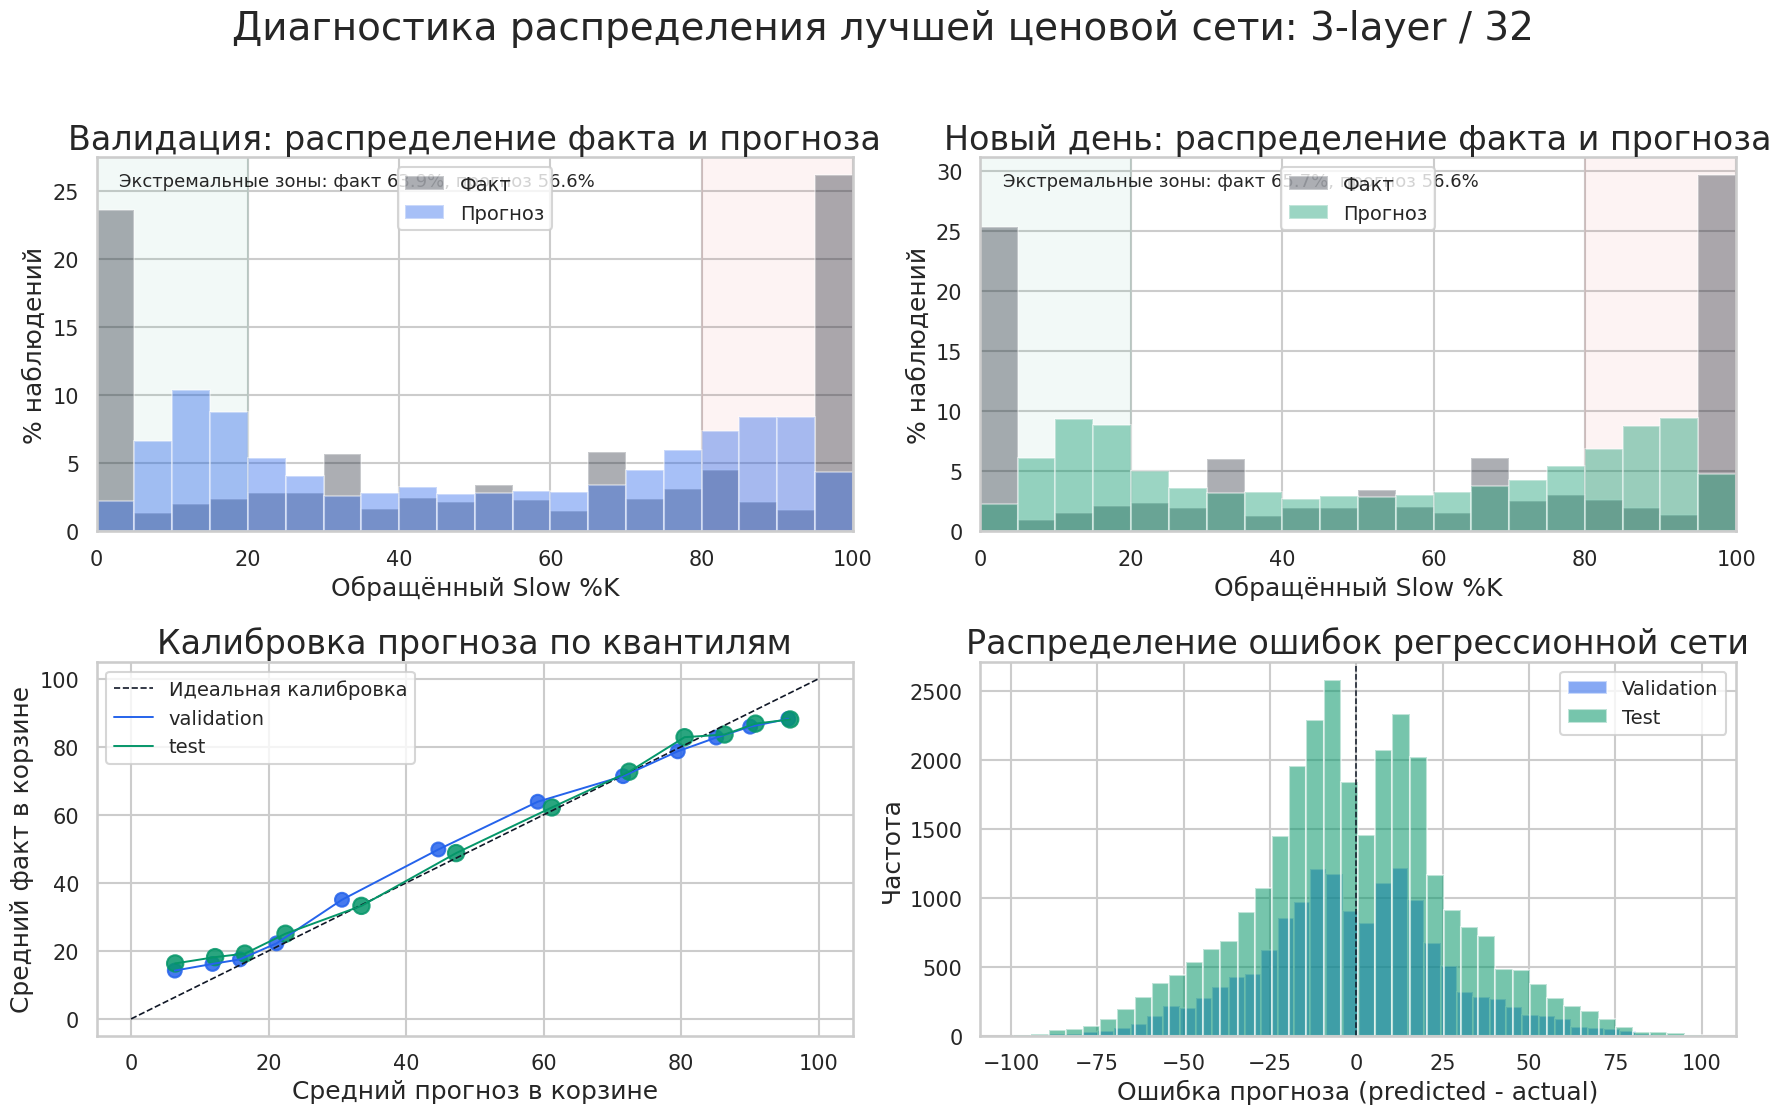

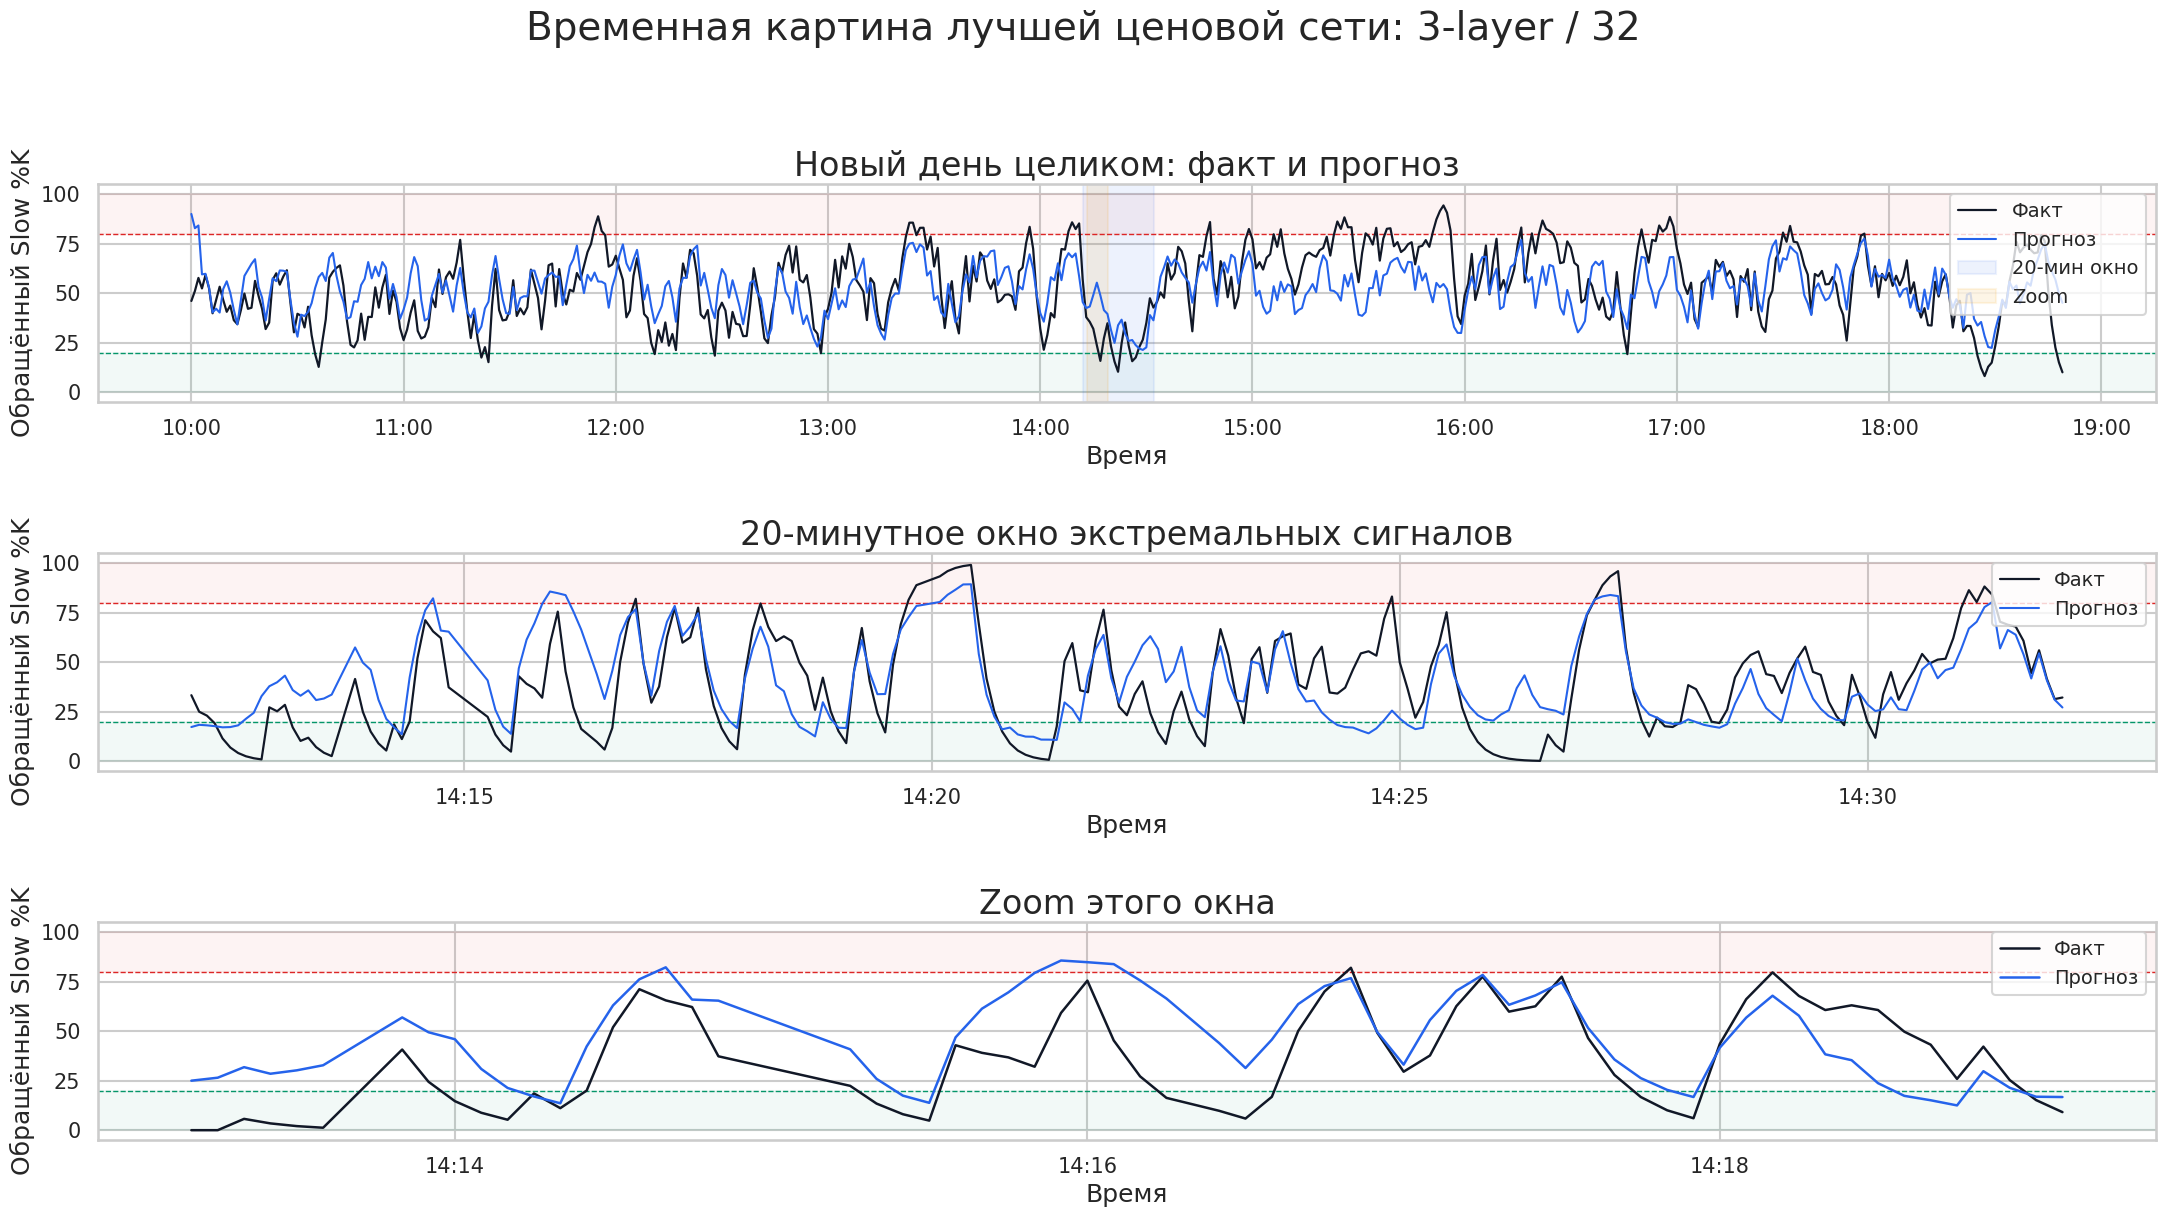

In [17]:
best_price_plot_name = table1.sort_values("Корреляция valid", ascending=False).iloc[0]["Название сети"]
price_pred_col = f"pred_price__{best_price_plot_name}"
valid_plot = evaluation_days["validation"].dropna(subset=["inv_slow_k", f"pred_price__{best_price_plot_name}"]).copy()
test_plot = evaluation_days["test"].dropna(subset=["inv_slow_k", f"pred_price__{best_price_plot_name}"]).copy()

price_focus_score = (
    ((test_plot["inv_slow_k"] >= 80) | (test_plot["inv_slow_k"] <= 20)).astype(float)
    + ((test_plot[price_pred_col] >= 80) | (test_plot[price_pred_col] <= 20)).astype(float)
    + (test_plot[price_pred_col] - test_plot["inv_slow_k"]).abs() / 40.0
)
price_focus = select_focus_window_from_score(test_plot, price_focus_score, window_minutes=20)
zoom_center = price_focus_score.loc[price_focus.index].idxmax()
zoom_window = price_focus.loc[
    max(price_focus.index.min(), zoom_center - pd.Timedelta(minutes=3)):
    min(price_focus.index.max(), zoom_center + pd.Timedelta(minutes=3))
].copy()

full_day_display = test_plot[["inv_slow_k", price_pred_col]].resample("1min").median().dropna()
focus_display = price_focus[["inv_slow_k", price_pred_col]].resample("5s").median().dropna()
zoom_display = zoom_window[["inv_slow_k", price_pred_col]].resample("5s").median().dropna()
for frame, span in [(full_day_display, 5), (focus_display, 4), (zoom_display, 4)]:
    frame["actual_smooth"] = frame["inv_slow_k"].ewm(span=span, adjust=False).mean()
    frame["pred_smooth"] = frame[price_pred_col].ewm(span=span, adjust=False).mean()

calibration_valid = regression_calibration_frame(valid_plot, price_pred_col, "inv_slow_k")
calibration_test = regression_calibration_frame(test_plot, price_pred_col, "inv_slow_k")
valid_residual = valid_plot[price_pred_col] - valid_plot["inv_slow_k"]
test_residual = test_plot[price_pred_col] - test_plot["inv_slow_k"]
dist_bins = np.arange(0, 105, 5)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

for ax, frame, title, color in [
    (axes[0, 0], valid_plot, "Валидация: распределение факта и прогноза", "#2563eb"),
    (axes[0, 1], test_plot, "Новый день: распределение факта и прогноза", "#059669"),
]:
    ax.axvspan(0, 20, color="#059669", alpha=0.05)
    ax.axvspan(80, 100, color="#dc2626", alpha=0.05)
    ax.hist(
        frame["inv_slow_k"],
        bins=dist_bins,
        weights=np.full(len(frame), 100 / len(frame)),
        color="#111827",
        alpha=0.35,
        label="Факт",
    )
    ax.hist(
        frame[price_pred_col],
        bins=dist_bins,
        weights=np.full(len(frame), 100 / len(frame)),
        color=color,
        alpha=0.40,
        label="Прогноз",
    )
    actual_extreme_share = ((frame["inv_slow_k"] <= 20) | (frame["inv_slow_k"] >= 80)).mean() * 100
    pred_extreme_share = ((frame[price_pred_col] <= 20) | (frame[price_pred_col] >= 80)).mean() * 100
    ax.text(
        0.03,
        0.96,
        f"Экстремальные зоны: факт {actual_extreme_share:.1f}%, прогноз {pred_extreme_share:.1f}%",
        transform=ax.transAxes,
        va="top",
        fontsize=13,
    )
    ax.set_title(title)
    ax.set_xlabel("Обращённый Slow %K")
    ax.set_ylabel("% наблюдений")
    ax.set_xlim(0, 100)
    ax.legend(loc="upper center")

axes[1, 0].plot([0, 100], [0, 100], "--", color="#111827", linewidth=1.2, label="Идеальная калибровка")
for frame, label, color in [
    (calibration_valid, "validation", "#2563eb"),
    (calibration_test, "test", "#059669"),
]:
    sizes = np.sqrt(frame["count"]) * 2.8
    axes[1, 0].plot(frame["pred_mean"], frame["actual_mean"], color=color, linewidth=1.4, label=label)
    axes[1, 0].scatter(frame["pred_mean"], frame["actual_mean"], color=color, s=sizes, alpha=0.85)
axes[1, 0].set_title("Калибровка прогноза по квантилям")
axes[1, 0].set_xlabel("Средний прогноз в корзине")
axes[1, 0].set_ylabel("Средний факт в корзине")
axes[1, 0].legend(loc="upper left")

axes[1, 1].hist(valid_residual, bins=40, alpha=0.55, color="#2563eb", label="Validation")
axes[1, 1].hist(test_residual, bins=40, alpha=0.55, color="#059669", label="Test")
axes[1, 1].axvline(0, color="#111827", linestyle="--", linewidth=1.1)
axes[1, 1].set_title("Распределение ошибок регрессионной сети")
axes[1, 1].set_xlabel("Ошибка прогноза (predicted - actual)")
axes[1, 1].set_ylabel("Частота")
axes[1, 1].legend()

fig.suptitle(f"Диагностика распределения лучшей ценовой сети: {best_price_plot_name}", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(22, 12), sharey=True)

for ax in axes:
    ax.axhspan(80, 100, color="#dc2626", alpha=0.05)
    ax.axhspan(0, 20, color="#059669", alpha=0.05)
    ax.axhline(80, color="#dc2626", linestyle="--", linewidth=1.0)
    ax.axhline(20, color="#059669", linestyle="--", linewidth=1.0)
    ax.set_ylim(-5, 105)

axes[0].plot(full_day_display.index, full_day_display["actual_smooth"], color="#111827", linewidth=1.6, label="Факт")
axes[0].plot(full_day_display.index, full_day_display["pred_smooth"], color="#2563eb", linewidth=1.5, label="Прогноз")
axes[0].axvspan(price_focus.index.min(), price_focus.index.max(), color="#2563eb", alpha=0.08, label="20-мин окно")
axes[0].axvspan(zoom_window.index.min(), zoom_window.index.max(), color="#f59e0b", alpha=0.10, label="Zoom")
axes[0].set_title("Новый день целиком: факт и прогноз")
axes[0].set_ylabel("Обращённый Slow %K")
axes[0].set_xlabel("Время")
axes[0].legend(loc="upper right")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axes[1].plot(focus_display.index, focus_display["actual_smooth"], color="#111827", linewidth=1.6, label="Факт")
axes[1].plot(focus_display.index, focus_display["pred_smooth"], color="#2563eb", linewidth=1.5, label="Прогноз")
axes[1].set_title("20-минутное окно экстремальных сигналов")
axes[1].set_ylabel("Обращённый Slow %K")
axes[1].set_xlabel("Время")
axes[1].legend(loc="upper right")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

axes[2].plot(zoom_display.index, zoom_display["actual_smooth"], color="#111827", linewidth=1.8, label="Факт")
axes[2].plot(zoom_display.index, zoom_display["pred_smooth"], color="#2563eb", linewidth=1.8, label="Прогноз")
axes[2].set_title("Zoom этого окна")
axes[2].set_ylabel("Обращённый Slow %K")
axes[2].set_xlabel("Время")
axes[2].legend(loc="upper right")
axes[2].xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle(f"Временная картина лучшей ценовой сети: {best_price_plot_name}", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98], h_pad=2.0)
plt.show()


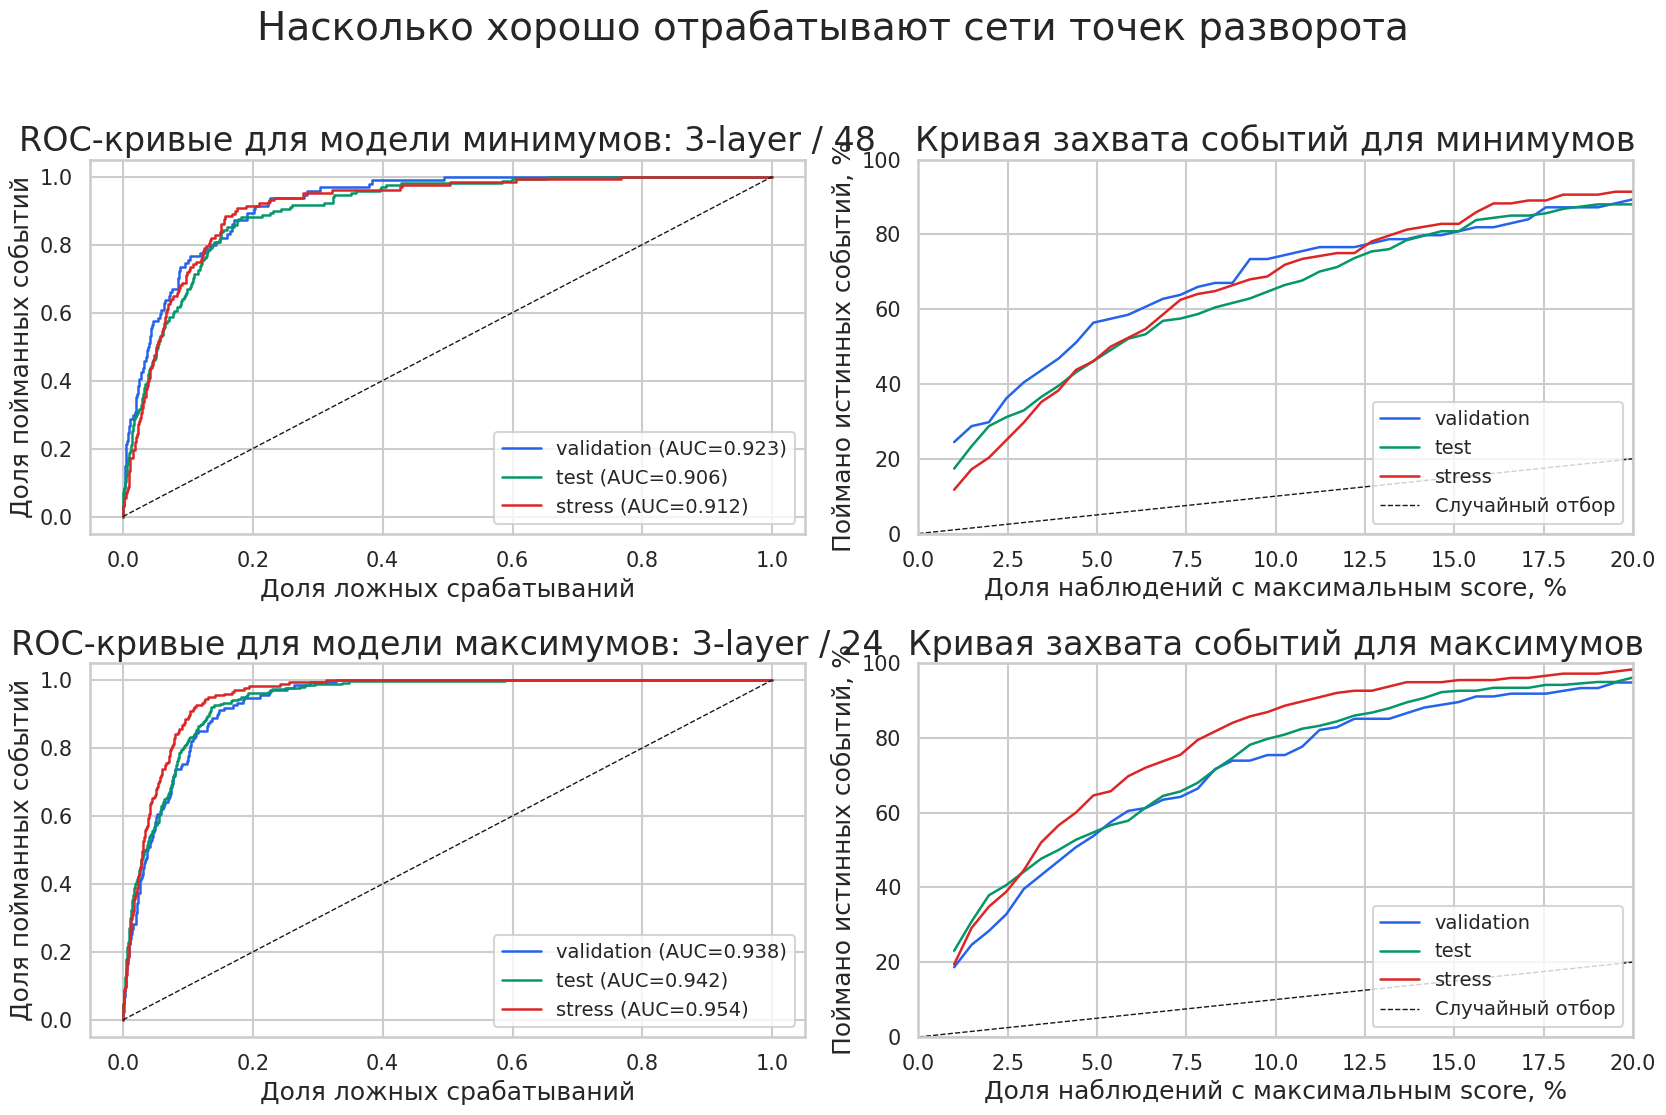

In [18]:
best_min_plot_name = table2.sort_values("ROC-AUC valid", ascending=False).iloc[0]["Название сети"]
best_max_plot_name = table3.sort_values("ROC-AUC valid", ascending=False).iloc[0]["Название сети"]

fig, axes = plt.subplots(2, 2, figsize=(17, 11))

for dataset_name, color in [("validation", "#2563eb"), ("test", "#059669"), ("stress", "#dc2626")]:
    ds = evaluation_days[dataset_name]

    mask_min = ds[[f"pred_min__{best_min_plot_name}", "is_min_turn"]].notna().all(axis=1)
    y_min = ds.loc[mask_min, "is_min_turn"].astype(int)
    p_min = ds.loc[mask_min, f"pred_min__{best_min_plot_name}"] / 100.0
    fpr_min, tpr_min, _ = roc_curve(y_min, p_min)
    capture_min = capture_curve_frame(y_min, p_min)
    axes[0, 0].plot(fpr_min, tpr_min, color=color, linewidth=1.8, label=f"{dataset_name} (AUC={roc_auc_score(y_min, p_min):.3f})")
    axes[0, 1].plot(capture_min["top_share"], capture_min["capture"], color=color, linewidth=1.8, label=f"{dataset_name}")

    mask_max = ds[[f"pred_max__{best_max_plot_name}", "is_max_turn"]].notna().all(axis=1)
    y_max = ds.loc[mask_max, "is_max_turn"].astype(int)
    p_max = ds.loc[mask_max, f"pred_max__{best_max_plot_name}"] / 100.0
    fpr_max, tpr_max, _ = roc_curve(y_max, p_max)
    capture_max = capture_curve_frame(y_max, p_max)
    axes[1, 0].plot(fpr_max, tpr_max, color=color, linewidth=1.8, label=f"{dataset_name} (AUC={roc_auc_score(y_max, p_max):.3f})")
    axes[1, 1].plot(capture_max["top_share"], capture_max["capture"], color=color, linewidth=1.8, label=f"{dataset_name}")

axes[0, 0].plot([0, 1], [0, 1], "--", color="#111827", linewidth=1.0)
axes[1, 0].plot([0, 1], [0, 1], "--", color="#111827", linewidth=1.0)
axes[0, 1].plot([0, 20], [0, 20], "--", color="#111827", linewidth=1.0, label="Случайный отбор")
axes[1, 1].plot([0, 20], [0, 20], "--", color="#111827", linewidth=1.0, label="Случайный отбор")
axes[0, 0].set_title(f"ROC-кривые для модели минимумов: {best_min_plot_name}")
axes[1, 0].set_title(f"ROC-кривые для модели максимумов: {best_max_plot_name}")
axes[0, 1].set_title("Кривая захвата событий для минимумов")
axes[1, 1].set_title("Кривая захвата событий для максимумов")

for ax in [axes[0, 0], axes[1, 0]]:
    ax.set_xlabel("Доля ложных срабатываний")
    ax.set_ylabel("Доля пойманных событий")
    ax.legend(loc="lower right")

for ax in [axes[0, 1], axes[1, 1]]:
    ax.set_xlabel("Доля наблюдений с максимальным score, %")
    ax.set_ylabel("Поймано истинных событий, %")
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right")

fig.suptitle("Насколько хорошо отрабатывают сети точек разворота", y=1.02)
plt.tight_layout()
plt.show()


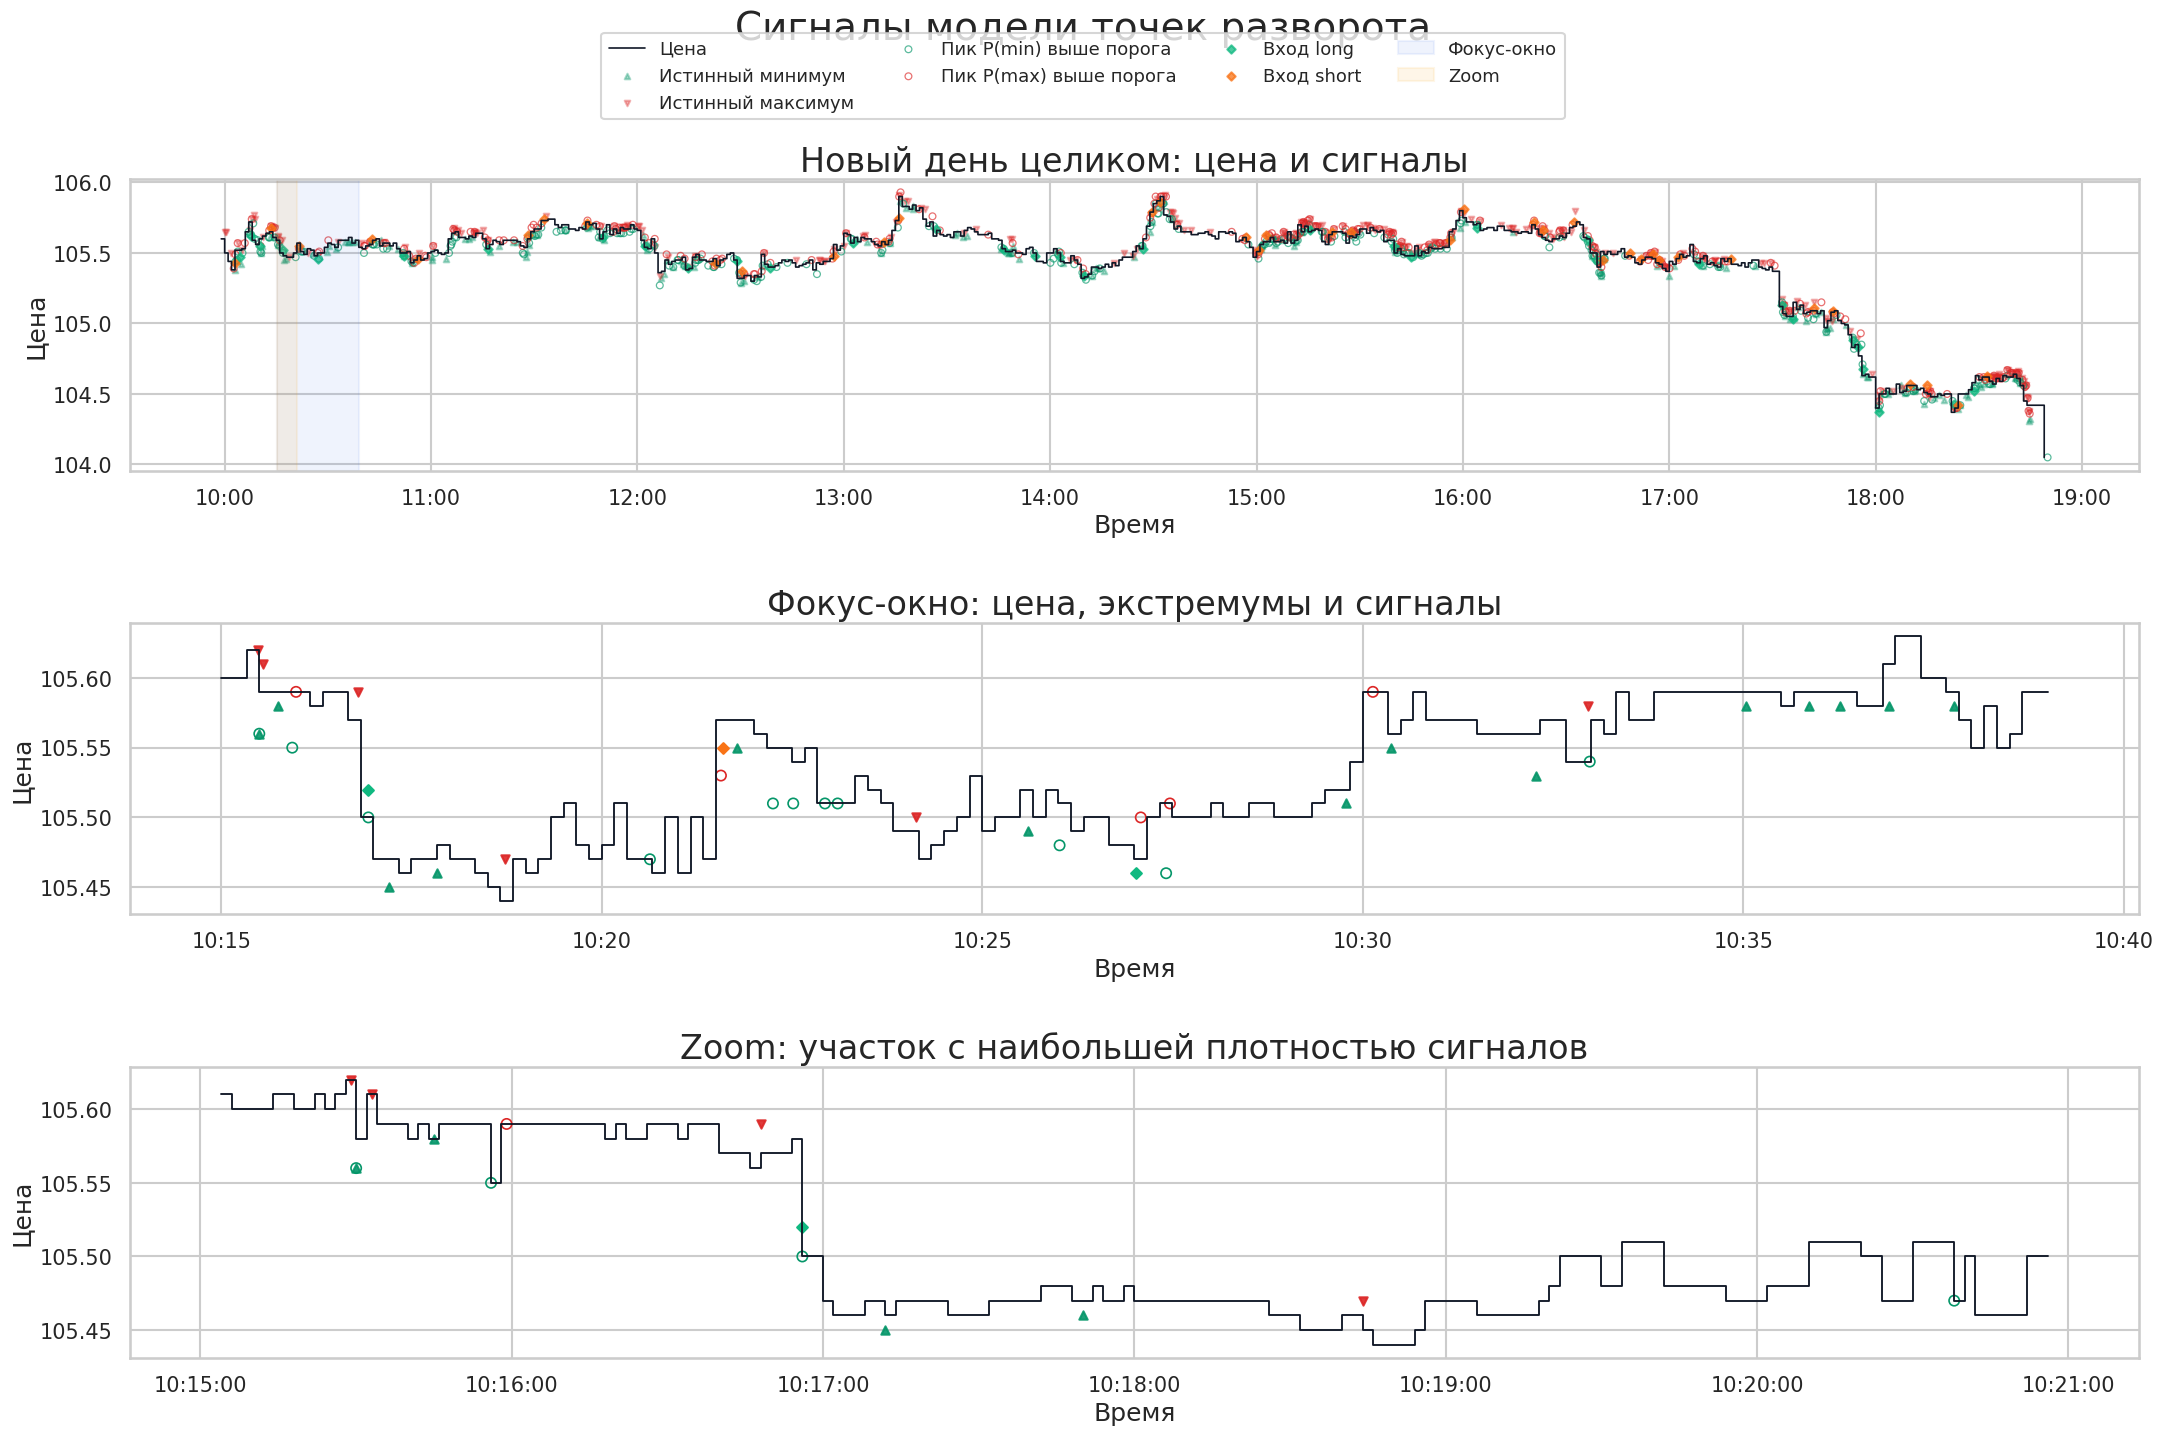

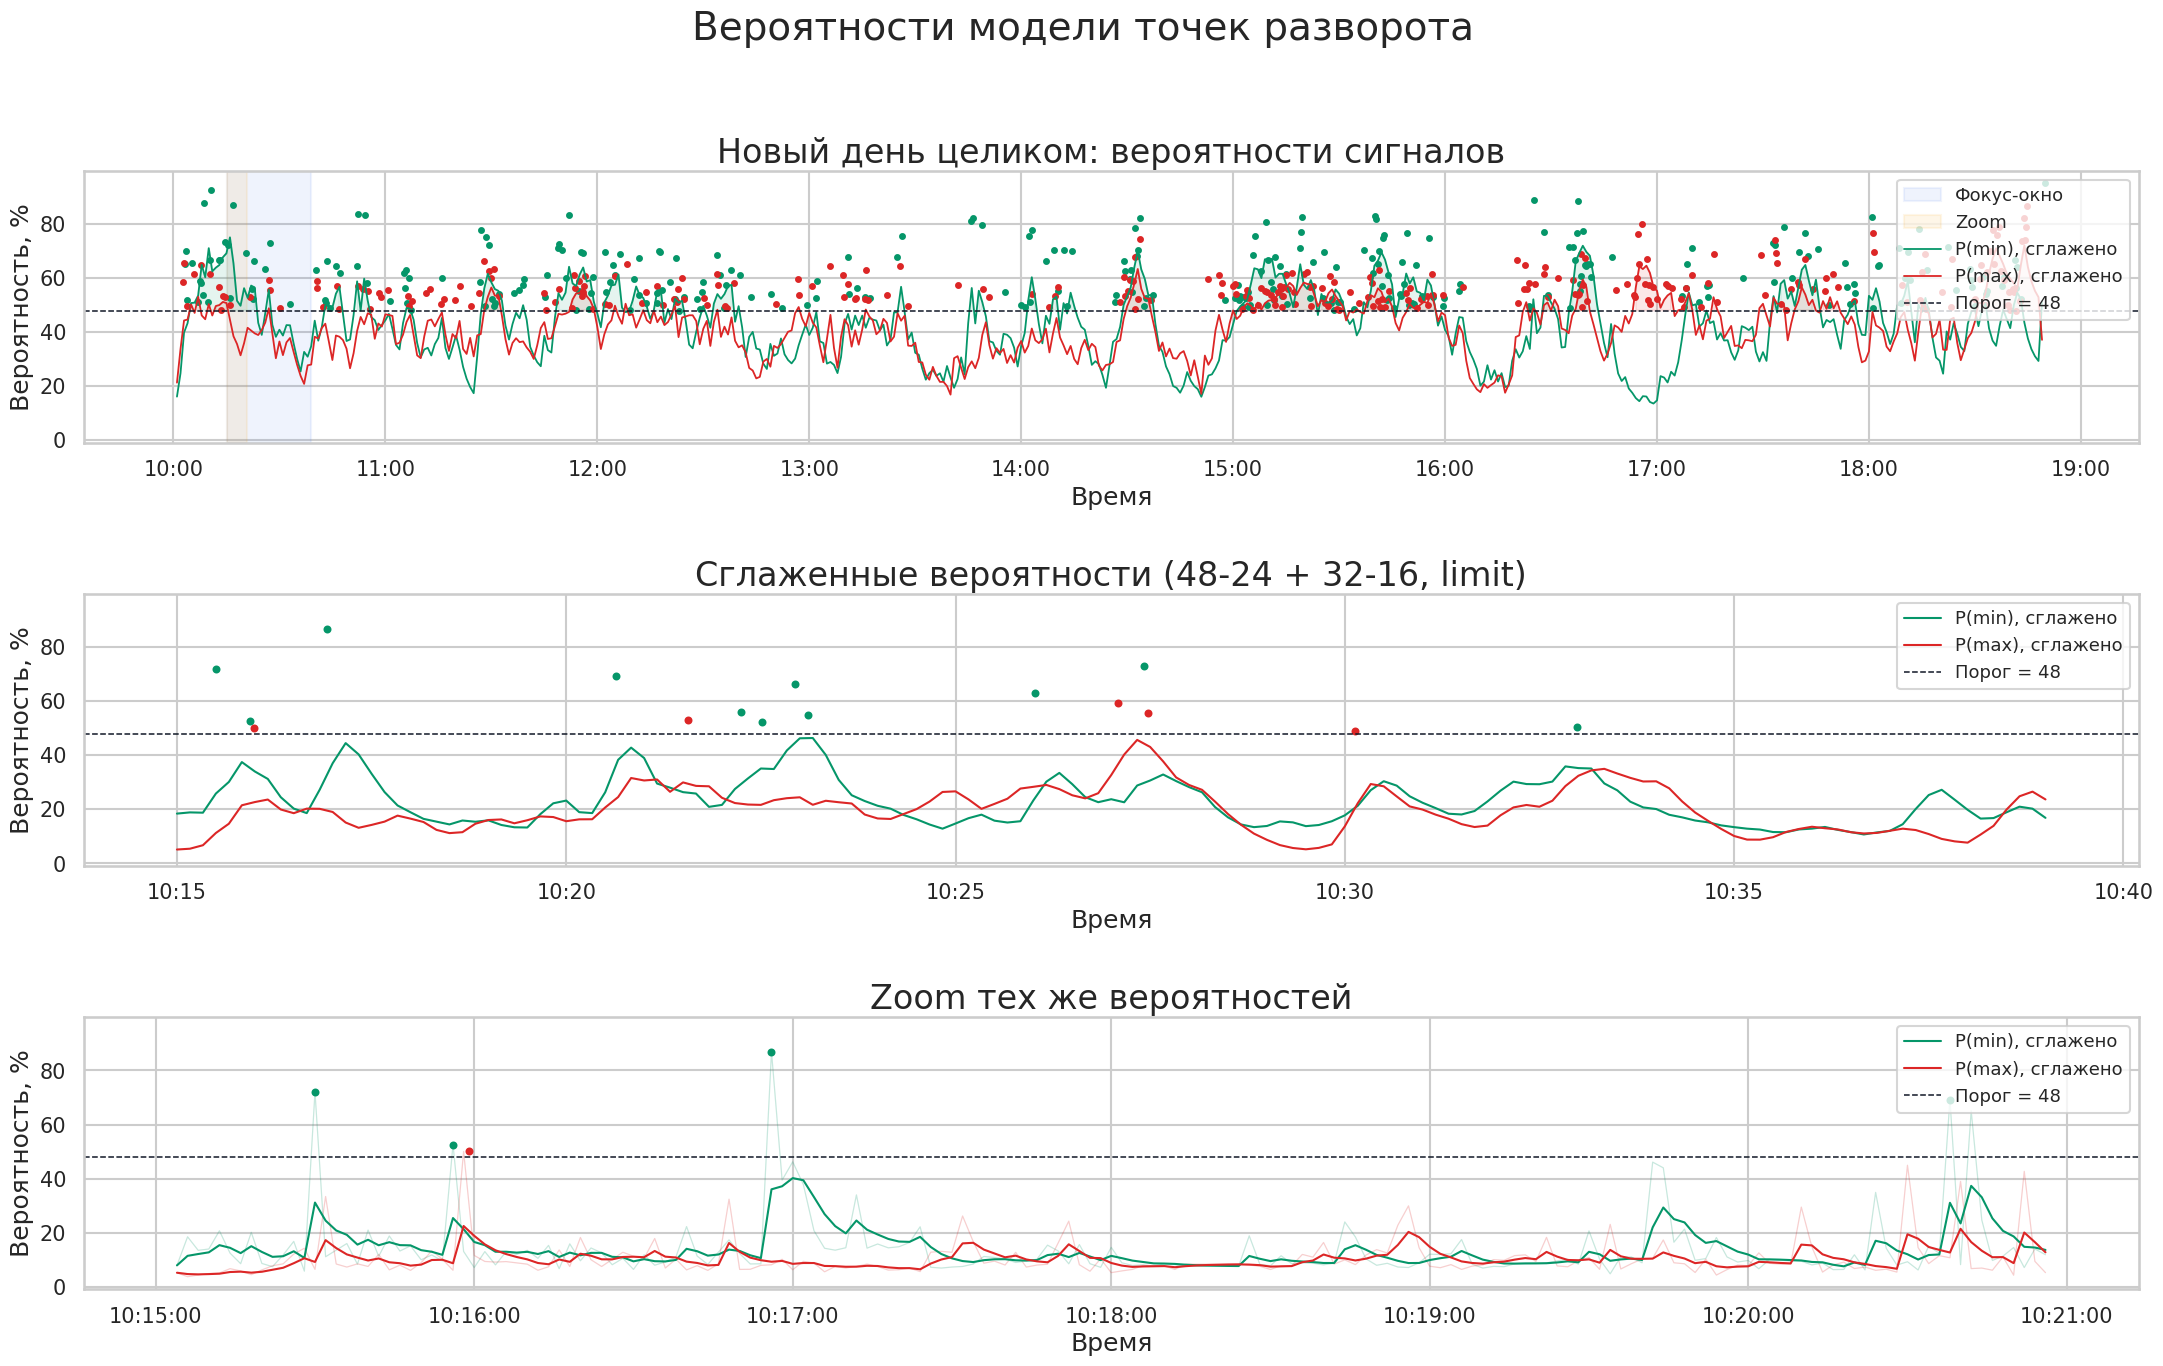

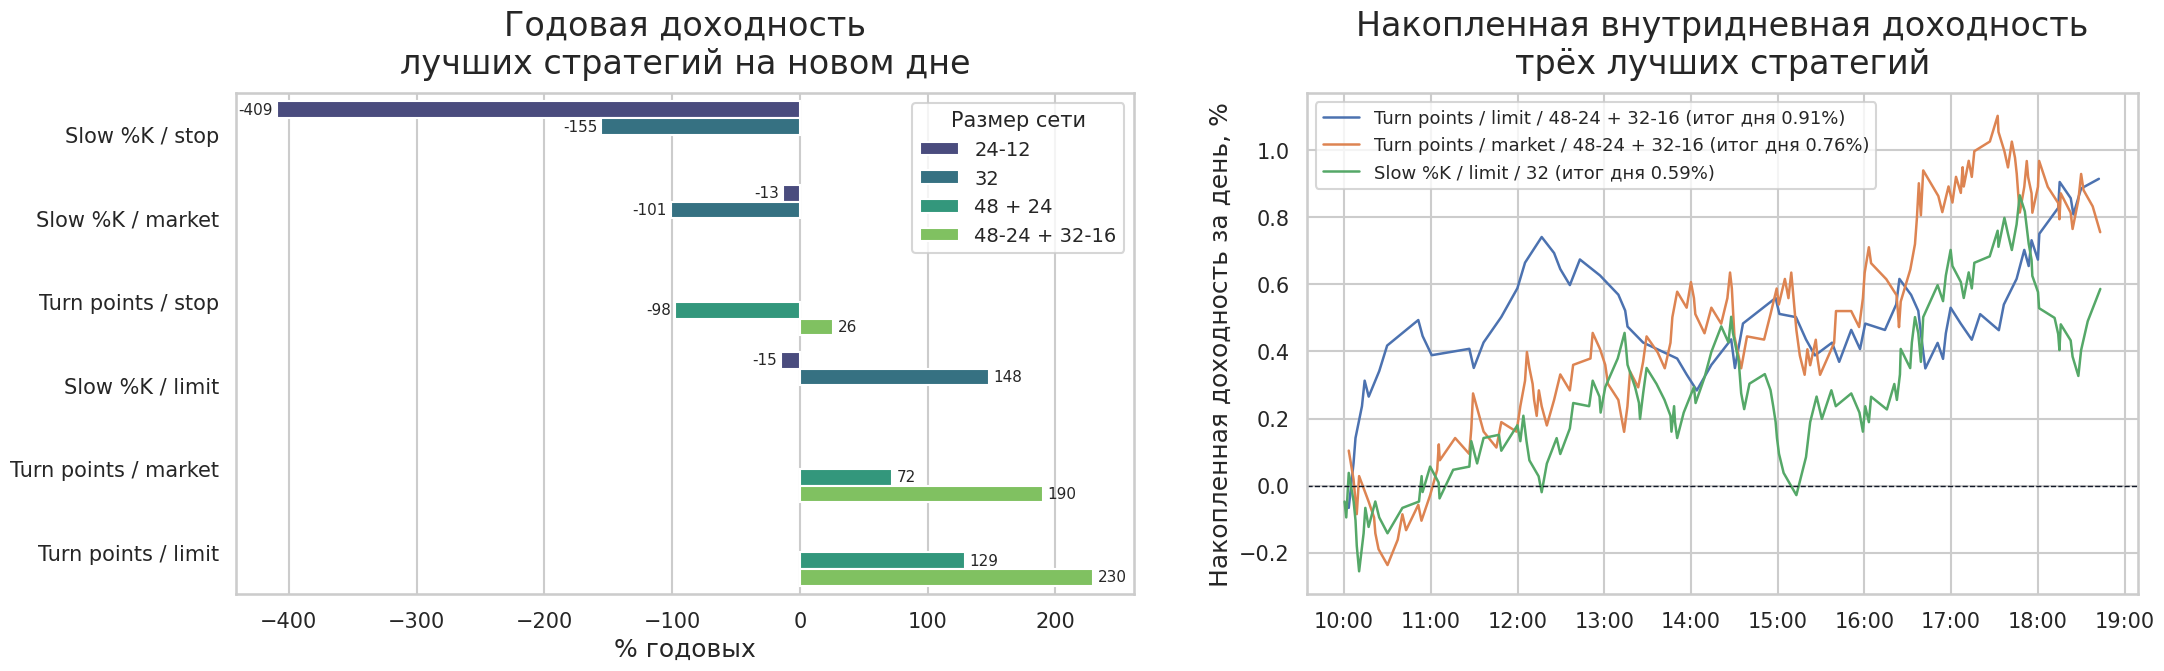

In [19]:
table4_test_diag = table4_test_sorted.merge(
    threshold_table[["Модель", "Размер сети", "Тип приказа", "Слои", "Название сети", "Min model", "Max model"]],
    left_on=["Название модели", "Размер сети", "Вид приказа"],
    right_on=["Модель", "Размер сети", "Тип приказа"],
    how="left",
)
table4_stress_diag = table4_stress_sorted.merge(
    threshold_table[["Модель", "Размер сети", "Тип приказа", "Слои", "Название сети", "Min model", "Max model"]],
    left_on=["Название модели", "Размер сети", "Вид приказа"],
    right_on=["Модель", "Размер сети", "Тип приказа"],
    how="left",
)

best_turn_row = (
    table4_test_diag.query("`Название модели` == 'Точки разворота (min/max)'")
    .sort_values("Доходность (% годовых)", ascending=False)
    .iloc[0]
)
best_turn_key = (best_turn_row["Название модели"], best_turn_row["Слои"], best_turn_row["Вид приказа"])
best_turn_trades = test_trades[best_turn_key]
turn_threshold = int(best_turn_row["Порог"])
turn_min_col = f"pred_min__{best_turn_row['Min model']}"
turn_max_col = f"pred_max__{best_turn_row['Max model']}"
turn_score = (
    (evaluation_days["test"][turn_min_col] - turn_threshold).clip(lower=0)
    + (evaluation_days["test"][turn_max_col] - turn_threshold).clip(lower=0)
) / 20.0
turn_window = select_focus_window_for_trades(
    evaluation_days["test"],
    trades=best_turn_trades,
    extra_score=turn_score,
    window_minutes=24,
)
turn_zoom_center = turn_score.loc[turn_window.index].idxmax()
turn_zoom = turn_window.loc[
    max(turn_window.index.min(), turn_zoom_center - pd.Timedelta(minutes=4)):
    min(turn_window.index.max(), turn_zoom_center + pd.Timedelta(minutes=4))
].copy()

turn_day = evaluation_days["test"].copy()
turn_day_display = turn_day[["close"]].resample("1min").last().ffill()
turn_day_prob = turn_day[[turn_min_col, turn_max_col]].resample("1min").max().ffill()
turn_day_display[turn_min_col] = turn_day_prob[turn_min_col].ewm(span=5, adjust=False).mean()
turn_day_display[turn_max_col] = turn_day_prob[turn_max_col].ewm(span=5, adjust=False).mean()

turn_display = turn_window[["close"]].resample("10s").last().ffill()
turn_display[turn_min_col] = (
    turn_window[turn_min_col].resample("10s").max().ffill().rolling(3, min_periods=1).mean().ewm(span=4, adjust=False).mean()
)
turn_display[turn_max_col] = (
    turn_window[turn_max_col].resample("10s").max().ffill().rolling(3, min_periods=1).mean().ewm(span=4, adjust=False).mean()
)
turn_zoom_raw = turn_zoom[[turn_min_col, turn_max_col]].resample("2s").max().ffill()
turn_zoom_display = turn_zoom[["close"]].resample("2s").last().ffill()
turn_zoom_display[turn_min_col] = turn_zoom_raw[turn_min_col].ewm(span=5, adjust=False).mean()
turn_zoom_display[turn_max_col] = turn_zoom_raw[turn_max_col].ewm(span=5, adjust=False).mean()

long_peaks_day = local_peak_mask(turn_day[turn_min_col], turn_threshold, neighborhood=12)
short_peaks_day = local_peak_mask(turn_day[turn_max_col], turn_threshold, neighborhood=12)
long_peaks_full = local_peak_mask(turn_window[turn_min_col], turn_threshold, neighborhood=8)
short_peaks_full = local_peak_mask(turn_window[turn_max_col], turn_threshold, neighborhood=8)
long_peaks_zoom = local_peak_mask(turn_zoom[turn_min_col], turn_threshold, neighborhood=8)
short_peaks_zoom = local_peak_mask(turn_zoom[turn_max_col], turn_threshold, neighborhood=8)
trade_entries_day = best_turn_trades.copy()
trade_entries_full = best_turn_trades[
    (best_turn_trades["entry_time"] >= turn_window.index.min()) & (best_turn_trades["entry_time"] <= turn_window.index.max())
]
trade_entries_zoom = best_turn_trades[
    (best_turn_trades["entry_time"] >= turn_zoom.index.min()) & (best_turn_trades["entry_time"] <= turn_zoom.index.max())
]

fig, axes = plt.subplots(3, 1, figsize=(22, 14.5), sharey=False)

for ax, frame_display, frame_raw, long_mask, short_mask, trades_slice, title, full_day in [
    (
        axes[0],
        turn_day_display,
        turn_day,
        long_peaks_day,
        short_peaks_day,
        trade_entries_day,
        "Новый день целиком: цена и сигналы",
        True,
    ),
    (
        axes[1],
        turn_display,
        turn_window,
        long_peaks_full,
        short_peaks_full,
        trade_entries_full,
        "Фокус-окно: цена, экстремумы и сигналы",
        False,
    ),
    (
        axes[2],
        turn_zoom_display,
        turn_zoom,
        long_peaks_zoom,
        short_peaks_zoom,
        trade_entries_zoom,
        "Zoom: участок с наибольшей плотностью сигналов",
        False,
    ),
]:
    ax.plot(
        frame_display.index,
        frame_display["close"],
        color="#111827",
        linewidth=1.2 if full_day else 1.35,
        drawstyle="steps-post",
        label="Цена",
    )
    ax.scatter(
        frame_raw.index[frame_raw["is_min_turn"] == 1],
        frame_raw.loc[frame_raw["is_min_turn"] == 1, "close"],
        color="#059669",
        marker="^",
        s=16 if full_day else 36,
        alpha=0.35 if full_day else 0.9,
        label="Истинный минимум",
    )
    ax.scatter(
        frame_raw.index[frame_raw["is_max_turn"] == 1],
        frame_raw.loc[frame_raw["is_max_turn"] == 1, "close"],
        color="#dc2626",
        marker="v",
        s=16 if full_day else 36,
        alpha=0.35 if full_day else 0.9,
        label="Истинный максимум",
    )
    ax.scatter(
        frame_raw.index[long_mask],
        frame_raw.loc[long_mask, "close"],
        facecolors="none",
        edgecolors="#059669",
        s=24 if full_day else 55,
        linewidth=0.9 if full_day else 1.2,
        alpha=0.65 if full_day else 1.0,
        label="Пик P(min) выше порога",
    )
    ax.scatter(
        frame_raw.index[short_mask],
        frame_raw.loc[short_mask, "close"],
        facecolors="none",
        edgecolors="#dc2626",
        s=24 if full_day else 55,
        linewidth=0.9 if full_day else 1.2,
        alpha=0.65 if full_day else 1.0,
        label="Пик P(max) выше порога",
    )
    if not trades_slice.empty:
        long_entries = trades_slice.query("direction == 1")
        short_entries = trades_slice.query("direction == -1")
        ax.scatter(
            long_entries["entry_time"],
            long_entries["entry_price"],
            marker="D",
            s=18 if full_day else 30,
            color="#10b981",
            alpha=0.75 if full_day else 1.0,
            label="Вход long",
        )
        ax.scatter(
            short_entries["entry_time"],
            short_entries["entry_price"],
            marker="D",
            s=18 if full_day else 30,
            color="#f97316",
            alpha=0.75 if full_day else 1.0,
            label="Вход short",
        )
    if full_day:
        ax.axvspan(turn_window.index.min(), turn_window.index.max(), color="#2563eb", alpha=0.07, label="Фокус-окно")
        ax.axvspan(turn_zoom.index.min(), turn_zoom.index.max(), color="#f59e0b", alpha=0.09, label="Zoom")
    ax.set_title(title)
    ax.set_ylabel("Цена")

unique_labels = {}
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label not in unique_labels:
            unique_labels[label] = handle
fig.legend(unique_labels.values(), unique_labels.keys(), loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=4, fontsize=13, frameon=True)

axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[0].set_xlabel("Время")
axes[1].set_xlabel("Время")
axes[2].set_xlabel("Время")

fig.suptitle("Сигналы модели точек разворота", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.965], h_pad=2.0)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(22, 13.8), sharey=True)

for ax, frame_display, frame_raw, long_mask, short_mask, title, full_day in [
    (
        axes[0],
        turn_day_display,
        turn_day,
        long_peaks_day,
        short_peaks_day,
        "Новый день целиком: вероятности сигналов",
        True,
    ),
    (
        axes[1],
        turn_display,
        turn_window,
        long_peaks_full,
        short_peaks_full,
        f"Сглаженные вероятности ({best_turn_row['Размер сети']}, {best_turn_row['Вид приказа']})",
        False,
    ),
    (
        axes[2],
        turn_zoom_display,
        turn_zoom,
        long_peaks_zoom,
        short_peaks_zoom,
        "Zoom тех же вероятностей",
        False,
    ),
]:
    if full_day:
        ax.axvspan(turn_window.index.min(), turn_window.index.max(), color="#2563eb", alpha=0.07, label="Фокус-окно")
        ax.axvspan(turn_zoom.index.min(), turn_zoom.index.max(), color="#f59e0b", alpha=0.09, label="Zoom")
    if ax is axes[2]:
        ax.plot(turn_zoom_raw.index, turn_zoom_raw[turn_min_col], color="#059669", linewidth=0.9, alpha=0.22)
        ax.plot(turn_zoom_raw.index, turn_zoom_raw[turn_max_col], color="#dc2626", linewidth=0.9, alpha=0.22)
    ax.plot(
        frame_display.index,
        frame_display[turn_min_col],
        color="#059669",
        linewidth=1.3 if full_day else 1.5,
        label="P(min), сглажено",
    )
    ax.plot(
        frame_display.index,
        frame_display[turn_max_col],
        color="#dc2626",
        linewidth=1.3 if full_day else 1.5,
        label="P(max), сглажено",
    )
    ax.axhline(turn_threshold, color="#111827", linestyle="--", linewidth=1.1, label=f"Порог = {turn_threshold}")
    ax.fill_between(frame_display.index, turn_threshold, frame_display[turn_min_col], where=frame_display[turn_min_col] >= turn_threshold, color="#059669", alpha=0.10)
    ax.fill_between(frame_display.index, turn_threshold, frame_display[turn_max_col], where=frame_display[turn_max_col] >= turn_threshold, color="#dc2626", alpha=0.10)
    ax.scatter(frame_raw.index[long_mask], frame_raw.loc[long_mask, turn_min_col], color="#059669", s=12 if full_day else 18)
    ax.scatter(frame_raw.index[short_mask], frame_raw.loc[short_mask, turn_max_col], color="#dc2626", s=12 if full_day else 18)
    ax.set_title(title)
    ax.set_ylabel("Вероятность, %")
    ax.legend(loc="upper right", fontsize=13)

axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[0].set_xlabel("Время")
axes[1].set_xlabel("Время")
axes[2].set_xlabel("Время")

fig.suptitle("Вероятности модели точек разворота", y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=2.0)
plt.show()


def build_equity_curve(trades: pd.DataFrame) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame(columns=["exit_time", "equity_pct"])
    eq = trades.sort_values("exit_time").copy()
    eq["equity_pct"] = ((1 + eq["return"]).cumprod() - 1) * 100
    return eq[["exit_time", "equity_pct"]]


fig, axes = plt.subplots(1, 2, figsize=(22, 7.2), gridspec_kw={"width_ratios": [1.08, 1]})

comparison_test = table4_test_sorted.copy()
comparison_test["Стратегия"] = (
    comparison_test["Название модели"]
    .replace(
        {
            "Обращённый Slow %K": "Slow %K",
            "Точки разворота (min/max)": "Turn points",
        }
    )
    + " / "
    + comparison_test["Вид приказа"]
)
comparison_test = comparison_test.sort_values("Доходность (% годовых)", ascending=True).reset_index(drop=True)
sns.barplot(
    data=comparison_test,
    y="Стратегия",
    x="Доходность (% годовых)",
    hue="Размер сети",
    orient="h",
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Годовая доходность\nлучших стратегий на новом дне", pad=14)
axes[0].set_xlabel("% годовых")
axes[0].set_ylabel("")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3, fontsize=11)

top3 = (
    table4_test_diag.sort_values("Доходность (% годовых)", ascending=False)
    .head(3)
    .reset_index(drop=True)
)
for _, row in top3.iterrows():
    key = (row["Название модели"], row["Слои"], row["Вид приказа"])
    eq = build_equity_curve(test_trades[key])
    if eq.empty:
        continue
    model_short = row["Название модели"].replace("Точки разворота (min/max)", "Turn points").replace("Обращённый Slow %K", "Slow %K")
    label = f"{model_short} / {row['Вид приказа']} / {row['Размер сети']} (итог дня {eq['equity_pct'].iloc[-1]:.2f}%)"
    axes[1].plot(eq["exit_time"], eq["equity_pct"], linewidth=1.8, label=label)

axes[1].axhline(0, color="#111827", linestyle="--", linewidth=1.0)
axes[1].set_title("Накопленная внутридневная доходность\nтрёх лучших стратегий", pad=14)
axes[1].set_ylabel("Накопленная доходность за день, %")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].legend(loc="best", fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.98], w_pad=3.0)
plt.show()


In [20]:
final_summary = pd.DataFrame(
    {
        "Блок": [
            "Цена / best 3-layer",
            "Цена / best 4-layer",
            "Минимумы / best 3-layer",
            "Минимумы / best 4-layer",
            "Максимумы / best 3-layer",
            "Максимумы / best 4-layer",
        ],
        "Выбранная сеть": [
            best_price.iloc[0]["Название сети"],
            best_price.iloc[1]["Название сети"],
            best_min.iloc[0]["Название сети"],
            best_min.iloc[1]["Название сети"],
            best_max.iloc[0]["Название сети"],
            best_max.iloc[1]["Название сети"],
        ],
        "Основной критерий": [
            best_price.iloc[0]["Корреляция valid"],
            best_price.iloc[1]["Корреляция valid"],
            best_min.iloc[0]["ROC-AUC valid"],
            best_min.iloc[1]["ROC-AUC valid"],
            best_max.iloc[0]["ROC-AUC valid"],
            best_max.iloc[1]["ROC-AUC valid"],
        ],
    }
)
display(Markdown("## Краткая сводка по лучшим архитектурам"))
display(final_summary)


## Краткая сводка по лучшим архитектурам

,Блок,Выбранная сеть,Основной критерий
0,Цена / best 3-layer,3-layer / 32,0.725811
1,Цена / best 4-layer,4-layer / 24-12,0.688524
2,Минимумы / best 3-layer,3-layer / 48,0.923191
3,Минимумы / best 4-layer,4-layer / 48-24,0.896475
4,Максимумы / best 3-layer,3-layer / 24,0.938163
5,Максимумы / best 4-layer,4-layer / 32-16,0.900793


## Выводы

1. Входные файлы корректно читаются в кодировке `cp1251`; арифметика `amount = price * qty * 10` подтверждается для всех трёх файлов.
2. Основная воспроизводимая постановка получена на паре **2013-03-14 → 2013-03-15**, потому что файл за `2013-01-14` в папке отсутствует.
3. Для модели цены регрессия по обращённому Медленному `%K` даёт заметную корреляцию уже на валидации внутри дня.
4. Для моделей точек разворота одного вектора `x_k` недостаточно для устойчивой классификации точных локальных экстремумов; поэтому в ноутбуке использованы дополнительные микроструктурные признаки из самого потока торгов.
5. Таблицы 1–3 позволяют выбрать лучшие 3- и 4-слойные сети, а таблица 4 показывает, как они ведут себя на новых данных и при разных типах приказов.
6. Внутридневная валидация и следующий торговый день дают разный результат, поэтому вывод по модели нужно делать не только по качеству обучения, но и по устойчивости out-of-sample.
